In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from Bio.Align import PairwiseAligner, substitution_matrices
from scipy.cluster.hierarchy import fcluster, linkage as sp_linkage
from scipy.spatial.distance import squareform

# Cross-reactivity clustering for PhIP-Seq hit peptides. 

## Pipeline: 
1. seed candidate pairs with reduced-alphabet k-mers (conservative substitution still matches)
2. score each candidate pair with BLOSUM62 Smith-Waterman. 
3. threshold + union-find into clusters

In [2]:
meta = pd.read_csv('lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv')
df = pd.read_csv('long_091826.csv')
hits = pd.read_csv('pep_hits_wo_taxa_to_remove_091826.csv').set_index('peptide')

In [3]:
hits = hits.drop(columns='Unnamed: 0')

In [4]:
sequences = hits['sequence'].to_dict() #this keeps the peptide index
print(len(hits), "hit peptides") 

1287 hit peptides


In [5]:
BLOSUM62 = substitution_matrices.load("BLOSUM62")

def make_aligner():
    aln = PairwiseAligner()
    aln.mode = 'local'
    aln.substitution_matrix = BLOSUM62
    aln.open_gap_score = -10 #same setting as peptide to protein alignment
    aln.extend_gap_score = -0.5
    return aln

def similarity_matrix(sequences, progress_every=200):
    idx     = list(sequences)
    aligner = make_aligner()
    seqs    = [str(sequences[i]).upper() for i in idx]
    selfs   = [aligner.score(s, s) for s in seqs]
    n, mat  = len(idx), np.eye(len(idx))
    for i in range(n):
        for j in range(i + 1, n):
            d = min(selfs[i], selfs[j])
            mat[i, j] = mat[j, i] = aligner.score(seqs[i], seqs[j]) / d if d else 0.0
        if progress_every and (i + 1) % progress_every == 0:
            print(f"  aligned {i+1}/{n} rows")
    return idx, mat

In [6]:
#gives every peptide pair a normalized alignment score

idx, mat = similarity_matrix(sequences)

  aligned 200/1287 rows
  aligned 400/1287 rows
  aligned 600/1287 rows
  aligned 800/1287 rows
  aligned 1000/1287 rows
  aligned 1200/1287 rows


In [7]:
THRESHOLD = 0.5

#hierarchical clustering works with distance, not similarity. So convert to distance by d = 1-s. so if two peptides are identical, 1-1 = 0. distance is 0.
def collapse(idx, mat, threshold=0.5):
    dist = 1.0 - mat #convert similarity to distance
    np.fill_diagonal(dist, 0.0) #force self-distance to zero
    Z    = sp_linkage(squareform(dist, checks=False), method='average') #squareform converts square matrix to condensed form. s-linkage just wants A-B, not the
    #entire matrix. also no diagonals and no duplicates e.t. B-A. checks=False don't spend time checking whether it's a valid symmetry distance metric. 
    #average then performs average-linkage clustering, which is the actual hierarchical clustering. finds closest pair, merges them. Then recalculates distances
    #between clusters using average linkage. Z sotres the entire history of these merges. linkage just keeps going until everything is in a giant cluster.

    flat = fcluster(Z, t=1.0 - threshold, criterion='distance') #cut the hierarchical tree at distance = 0.5. so say I only want to merges that occured at <= 0.5

    labels = {pid: int(c) for pid, c in zip(idx, flat)} #attach cluster numbers to peptide IDs
    n_cl = len(set(flat)) #count number of clusters
    print(f"{len(idx)} peptides -> {n_cl} clusters ({len(idx)/n_cl:.2f}x collapse)") #tells how much redundancy was collapsed
    return labels #return the peptide -> cluster dictionary

#labels gives every peptide a cluster ID
labels = collapse(idx, mat, threshold=THRESHOLD)
hits['cluster'] = hits.index.map(labels)

1287 peptides -> 945 clusters (1.36x collapse)


In [8]:
r = df[df.reactive].copy()
lib = meta

r['cluster'] = r.peptide.map(labels)
r['species'] = r.peptide.map(hits['species'])

r

,peptide,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,cohort,category,reactive,cluster
5,AAR85463.1|protein|Orthomarburgvirus_marburgen...,C-109-3_4_E7,6.763416,25.271245,IPPPLPTARPEIKLTSTPTDATKLNTTDPSSDDEDLATSGSGSGER,Orthomarburgvirus marburgense,Orthomarburgvirus,Filoviridae,glycoprotein,AAR85463.1,SL,Household contact,True,393
6,AAT88081.1|protein|Mammarenavirus_piritalense|...,C-109-3_4_E7,18.991738,262.863342,VLEVKSREKMFVSETPGQRNPYENLLYKLCLSGDGWPYIGSRSQIK,Mammarenavirus piritalense,Mammarenavirus,Arenaviridae,nucleoprotein,AAT88081.1,SL,Household contact,True,198
14,ABI96821.1|protein|Mammarenavirus_choriomening...,C-109-3_4_E7,4.238116,4.380587,SRCIEMDGADKSGCIHNHDDKSVETILIESGIVCPGLPLIIPDGYK,Mammarenavirus choriomeningitidis,Mammarenavirus,Arenaviridae,polymerase,ABI96821.1,SL,Household contact,True,97
21,ABW96599.1|protein|North_American_arenavirus|?...,C-109-3_4_E7,3.910332,5.842765,AKYPNLTDLKVLTEKHPSLKIITQEESQVNISGYNLSLSAAVKAGA,Mammarenavirus whitewaterense,Mammarenavirus,Arenaviridae,nucleoprotein,ABW96599.1,SL,Household contact,True,604
46,ADX32840.1|precursor|Menekre_virus|?|Hylomyscu...,C-109-3_4_E7,9.473604,17.053521,AIAKCNLQHDEEFCDMLRLFDFNLQAIKRLKKESQNSLNLITKAVN,Menekre virus,Arenavirus,Arenaviridae,glycoprotein,ADX32840.1,SL,Household contact,True,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510803,YP_010839697.1|glycoprotein|Leticia_virus|isol...,S-513_SA3_I2,3.754988,7.766890,EGITGTNSYSFLESSKGGFAIHDEEFSDIPREGYLGEIRCSSESAV,Phlebovirus leticiaense,Phlebovirus,Phenuiviridae,glycoprotein,YP_010839697.1,SL,Lassa survivor,True,130
510823,YP_010839739.1|precursor|Pena_Blanca_virus|iso...,S-513_SA3_I2,6.606580,23.947910,SRQAEKEISQLKKDLTETLSVQDRLIESESLLTQKLKEVTLSMNLD,Phlebovirus penablancaense,Phlebovirus,Phenuiviridae,glycoprotein,YP_010839739.1,SL,Lassa survivor,True,830
510826,YP_010839744.1|polymerase|Tico_virus|isolate=?...,S-513_SA3_I2,5.916468,9.708612,STNPEERSRYHRTTIGLSRAESEYVATHGVRGKAHKDESQVVESRI,Phlebovirus ticoense,Phlebovirus,Phenuiviridae,polymerase,YP_010839744.1,SL,Lassa survivor,True,679
510896,YP_010840008.1|polymerase|coleopteran_phenui-r...,S-513_SA3_I2,4.178201,2.912584,FPMEMMTHPKNKESSIIEHKRNVHVKFGKQPSILIATSDDAEKWNQ,Pidchovirus stethori,Pidchovirus,Phenuiviridae,polymerase,YP_010840008.1,SL,Lassa survivor,True,663


In [9]:
r = df[df.reactive].copy()
lib = meta

r['cluster'] = r.peptide.map(labels)
r['species'] = r.peptide.map(hits['species'])

obs_s = (r.groupby(['species','individual'])['cluster'].nunique() #first gives a series indexed by (species,individual) where the value is 
         #how many distinct epitope clusters that person is reactive to for that species
           .groupby('species').mean().rename('mean_epitopes')) #collapses the individual level, averaging across people. so mean epitopes is the number of independent epitope clusters a person has for that species

pep_s = (r.groupby(['species','individual'])['peptide'].nunique() #gives series indexed by (species, individual) with the value being unique peptides for that person for that species
           .groupby('species').mean().rename('mean_peptides'))
lib_s = lib.groupby('species').size().rename('lib_peptides')
ind_s = r.groupby('species')['individual'].nunique().rename('n_individuals')

ds = pd.concat([obs_s, pep_s, lib_s, ind_s], axis=1).dropna()
ds = ds[(ds.lib_peptides >= 100) & (ds.n_individuals >= 20)]

for col, name in [('mean_peptides','resid_peptide'), ('mean_epitopes','resid_epitope')]:
    xx, yy = np.log10(ds.lib_peptides), np.log10(ds[col])
    bb, aa = np.polyfit(xx, yy, 1)
    ds[name] = yy - (aa + bb*xx)

ds.sort_values('resid_epitope', ascending=False)[
    ['lib_peptides','mean_peptides','mean_epitopes','resid_peptide','resid_epitope']].round(3).head(10)

,lib_peptides,mean_peptides,mean_epitopes,resid_peptide,resid_epitope
species,,,,,
Mammarenavirus lassaense,4494,7.440,4.908,0.435,0.309
Orthonairovirus haemorrhagiae,2524,3.529,3.372,0.182,0.208
Orthoflavivirus denguei,2050,3.037,2.891,0.143,0.163
Phlebovirus ambeense,170,1.498,1.498,0.143,0.145
Nairoviridae sp.,1160,2.293,2.293,0.091,0.124
Phlebovirus baishanense,247,1.509,1.509,0.101,0.108
Uukuvirus dabieshanense,103,1.201,1.201,0.109,0.103
Orthonairovirus nairobiense,333,1.569,1.569,0.081,0.093
Phlebovirus riograndense,167,1.316,1.316,0.089,0.091


In [10]:
ds['collapse'] = 1 - ds.mean_epitopes / ds.mean_peptides
ds.sort_values('collapse', ascending=False)[['lib_peptides','mean_peptides','mean_epitopes','collapse']].sort_values(by='collapse', ascending=False).head(10)

,lib_peptides,mean_peptides,mean_epitopes,collapse
species,,,,
Mammarenavirus lassaense,4494,7.440204,4.908397,0.340287
Hartmanivirus turici,246,1.588957,1.104294,0.305019
Reptarenavirus giessenae,183,1.269231,1.000000,0.212121
Orthoflavivirus zikaense,512,1.582353,1.276471,0.193309
Mammarenavirus whitewaterense,647,1.773333,1.448889,0.182957
Orthoebolavirus restonense,237,1.306306,1.135135,0.131034
Mammarenavirus choriomeningitidis,2267,2.124260,1.890533,0.110028
Trypanosoma cruzi,471,1.744094,1.555118,0.108352
Uukuvirus hoplandense,106,1.120690,1.000000,0.107692


In [11]:
# how much of each species' epitope breadth is SHARED with other taxa?
cl = hits.copy()
cl['cluster'] = cl.index.map(labels)
cl_species = cl.groupby('cluster')['species'].nunique()
cl_genus   = cl.groupby('cluster')['genus'].nunique()

react = df[df.reactive].copy()
react['cluster'] = react.peptide.map(labels)
react['species'] = react.peptide.map(hits['species'])

e = react.drop_duplicates(['species','cluster']).copy()
e['shared_species'] = e.cluster.map(cl_species) > 1     # cluster spans >1 species
e['shared_genus']   = e.cluster.map(cl_genus)   > 1     # cluster spans >1 genus

cross = e.groupby('species').agg(n_epitopes=('cluster','nunique'),
                                 n_shared_sp=('shared_species','sum'),
                                 n_shared_gen=('shared_genus','sum'))
cross['cross_species_frac'] = cross.n_shared_sp  / cross.n_epitopes
cross['cross_genus_frac']   = cross.n_shared_gen / cross.n_epitopes

ds = ds.join(cross[['n_epitopes','cross_species_frac','cross_genus_frac']])
ds.sort_values('resid_epitope', ascending=False)[
    ['lib_peptides','mean_peptides','mean_epitopes','resid_epitope',
     'collapse','cross_species_frac','cross_genus_frac']].round(3).head(10)

,lib_peptides,mean_peptides,mean_epitopes,resid_epitope,collapse,cross_species_frac,cross_genus_frac
species,,,,,,,
Mammarenavirus lassaense,4494,7.440,4.908,0.309,0.340,0.343,0.057
Orthonairovirus haemorrhagiae,2524,3.529,3.372,0.208,0.044,0.152,0.000
Orthoflavivirus denguei,2050,3.037,2.891,0.163,0.048,0.080,0.000
Phlebovirus ambeense,170,1.498,1.498,0.145,0.000,0.429,0.000
Nairoviridae sp.,1160,2.293,2.293,0.124,0.000,0.211,0.000
Phlebovirus baishanense,247,1.509,1.509,0.108,0.000,0.167,0.000
Uukuvirus dabieshanense,103,1.201,1.201,0.103,0.000,0.000,0.000
Orthonairovirus nairobiense,333,1.569,1.569,0.093,0.000,0.000,0.000
Phlebovirus riograndense,167,1.316,1.316,0.091,0.000,0.333,0.000


In [12]:
react = df[df.reactive].copy()
react['cluster'] = react.peptide.map(labels)
react['genus']   = react.peptide.map(hits['genus'])
n_total = df.loc[df.cohort == 'SL', 'individual'].nunique()

g = (react.groupby('genus')
          .agg(n_peptides=('peptide','nunique'),
               n_epitopes=('cluster','nunique'),
               n_individuals=('individual','nunique'))
          .sort_values('n_epitopes', ascending=False))
g['prevalence'] = (100 * g.n_individuals / n_total).round(0)
g['unique']   = (100 * (g.n_epitopes / g.n_peptides)).round(0)

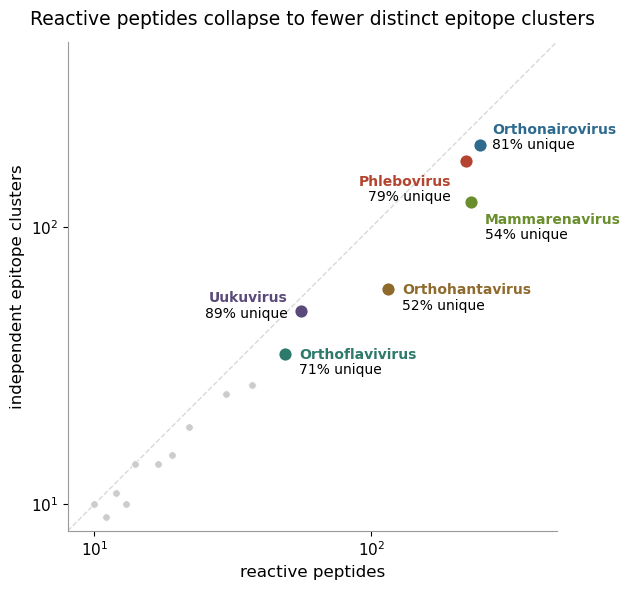

In [13]:
TOPN     = 6
top_gen  = list(g.nlargest(TOPN, 'n_epitopes').index)
PALETTE  = ['#2d6a8e', '#b4432f', '#6a8e2d', '#8e6a2d', '#5a4a7a', '#2d7a6a']
HI       = {gen: PALETTE[i] for i, gen in enumerate(top_gen)}


OFF = {'Orthonairovirus':(9, 8,'left'),  'Phlebovirus':(-11,-18,'right'),
       'Mammarenavirus':(10,-16,'left'), 'Orthohantavirus':(10,-4,'left'),
       'Uukuvirus':(-10,6,'right'),      'Orthoflavivirus':(10,-4,'left'),
       'Reptarenavirus':(-10,-6,'right')}

# --- plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 6))
lim = [8, g.n_peptides.max()*1.9]

sub = g[g.n_peptides >= 8]
for gen, row in sub.iterrows():
    hl = gen in HI
    ax.scatter(row.n_peptides, row.n_epitopes,
               s=100 if hl else 30,
               color=HI.get(gen, '0.80'),
               edgecolor='white', lw=1.2 if hl else .6,
               zorder=4 if hl else 2)

for gen in HI:
    if gen not in sub.index: continue
    row = sub.loc[gen]
    dx, dy, ha = OFF.get(gen, (10, -4, 'left'))
    ax.annotate(gen, (row.n_peptides, row.n_epitopes), fontsize=10,
                color=HI[gen], fontweight='semibold', ha=ha,
                xytext=(dx, dy), textcoords='offset points', zorder=5)
    ax.annotate(f'{row["unique"]:.0f}% unique',
                (row.n_peptides, row.n_epitopes), fontsize=10, color='black', ha=ha,
                xytext=(dx, dy-11), textcoords='offset points', zorder=5)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_aspect('equal')

ax.set_xlabel('reactive peptides', fontsize=12)
ax.set_ylabel('independent epitope clusters', fontsize=12)
ax.set_title('Reactive peptides collapse to fewer distinct epitope clusters', fontsize=13.5, pad=12)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('0.6')

ax.plot(lim, lim, ls='--', color='0.85', lw=1, zorder=1)

ax.tick_params(axis='both', labelsize=11, which='major')
ax.tick_params(which='minor', length=0)

plt.tight_layout()

plt.savefig('peps_vs_epitope_breadth_genera.svg', format='svg')
plt.show()

In [27]:
cl = hits.copy(); cl['cluster'] = cl.index.map(labels)
nsp = cl.groupby('cluster')['species'].nunique()

sp_cl = (cl.drop_duplicates(['species','cluster'])
           .assign(specific=lambda t: t.cluster.map(nsp) == 1))

comp = (sp_cl.groupby(['genus','species'])
             .agg(clusters_incl_shared=('cluster','nunique'),
                  clusters_specific=('specific','sum'))
             .reset_index())

rows = []
for gen in top_gen:
    v = comp[comp.genus == gen]
    distinct = g.loc[gen, 'n_epitopes']
    top = v.nlargest(1, 'clusters_specific').iloc[0]      # one species
    rows.append({'genus': gen, 'n_species': len(v), 'distinct_clusters': distinct,
                 'top_species': top.species,
                 'pct_incl_shared': round(100*top.clusters_incl_shared/distinct, 1),
                 'pct_specific':    round(100*top.clusters_specific/distinct, 1)})
tt = pd.DataFrame(rows).sort_values('pct_incl_shared')
tt

,genus,n_species,distinct_clusters,top_species,pct_incl_shared,pct_specific
1,Phlebovirus,75,174,Phlebovirus baishanense,3.4,2.9
3,Orthohantavirus,50,60,Orthohantavirus hantanense,8.3,5.0
0,Orthonairovirus,53,199,Orthonairovirus haemorrhagiae,16.6,14.1
4,Uukuvirus,23,50,Uukuvirus uukuniemiense,18.0,18.0
2,Mammarenavirus,49,124,Mammarenavirus lassaense,28.2,18.5
5,Orthoflavivirus,5,35,Orthoflavivirus denguei,71.4,65.7


In [18]:
rows = []
for gen in top_gen:
    v = comp[comp.genus == gen]
    distinct = g.loc[gen, 'n_epitopes']
    top = v.nlargest(1, 'clusters_specific').iloc[0]
    rows.append({
        'Genus': gen,
        'Species represented': len(v),
        'Reactive peptides': int(g.loc[gen, 'n_peptides']),
        'Distinct epitope clusters': int(distinct),
        'Most reactive species': top.species,
        'Clusters containing it': int(top.clusters_incl_shared),
        '% of genus clusters': round(100*top.clusters_incl_shared/distinct, 1),
        'Clusters specific to it': int(top.clusters_specific),
        '% specific': round(100*top.clusters_specific/distinct, 1),
    })

tbl = (pd.DataFrame(rows)
         .sort_values('Distinct epitope clusters', ascending=False)
         .reset_index(drop=True))

tbl.to_csv('table1_genus_species.csv', index=False)
tbl


print(tbl.to_markdown(index=False))                      # Word / Google Docs
#print(tbl.to_latex(index=False, escape=False))           # LaTeX

| Genus           |   Species represented |   Reactive peptides |   Distinct epitope clusters | Most reactive species         |   Clusters containing it |   % of genus clusters |   Clusters specific to it |   % specific |
|:----------------|----------------------:|--------------------:|----------------------------:|:------------------------------|-------------------------:|----------------------:|--------------------------:|-------------:|
| Orthonairovirus |                    53 |                 247 |                         199 | Orthonairovirus haemorrhagiae |                       33 |                  16.6 |                        28 |         14.1 |
| Phlebovirus     |                    75 |                 220 |                         174 | Phlebovirus baishanense       |                        6 |                   3.4 |                         5 |          2.9 |
| Mammarenavirus  |                    49 |                 230 |                         124 | Mammarenavirus l

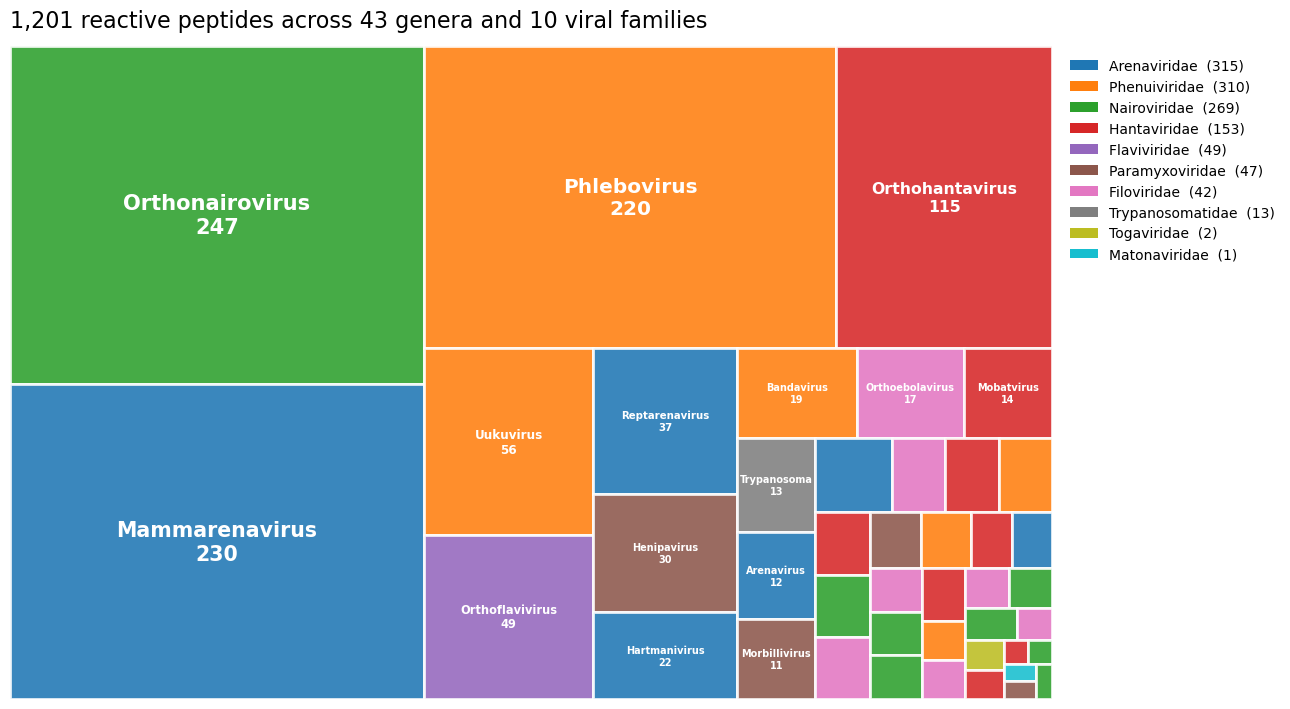

In [35]:
import squarify
from matplotlib.patches import Rectangle

VALUE = 'peptides'        # or 'clusters'

h = hits.copy()
h['cluster'] = h.index.map(labels)
tm = (h.groupby(['family','genus'])
        .agg(peptides=('sequence','size'), clusters=('cluster','nunique'))
        .reset_index()
        .rename(columns={VALUE:'n'})
        .sort_values('n', ascending=False))
tm = tm[tm.n > 0]

fams = tm.groupby('family').n.sum().sort_values(ascending=False)
cmap = plt.get_cmap('tab10')
FCOL = {f: cmap(i % 10) for i, f in enumerate(fams.index)}

fig, ax = plt.subplots(figsize=(13, 7.2))
rects = squarify.squarify(squarify.normalize_sizes(tm.n.to_numpy(float), 100, 62),
                          0, 0, 100, 62)

for r, (_, row) in zip(rects, tm.iterrows()):
    ax.add_patch(Rectangle((r['x'], r['y']), r['dx'], r['dy'],
                           facecolor=FCOL[row.family], edgecolor='white', lw=2, alpha=.88))
    area = r['dx']*r['dy']
    if area > 55:
        ax.text(r['x']+r['dx']/2, r['y']+r['dy']/2, f"{row.genus}\n{row.n}",
                ha='center', va='center', fontsize=np.clip(area**0.38, 7, 17),
                color='white', fontweight='semibold', linespacing=1.25)

ax.set_xlim(0, 100); ax.set_ylim(0, 62); ax.axis('off'); ax.invert_yaxis()
ax.set_title(f'{tm.n.sum():,} reactive peptides across {tm.genus.nunique()} genera '
             f'and {tm.family.nunique()} viral families', fontsize=16, loc='left', pad=14)
ax.legend([Rectangle((0,0),1,1, facecolor=FCOL[f]) for f in fams.index],
          [f'{f}  ({fams[f]})' for f in fams.index],
          frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(1.005, 1.0))
plt.tight_layout()
plt.savefig('fig_breadth_treemap.pdf', bbox_inches='tight')

### OLD 

In [20]:
# where the genus signal actually comes from
uuk = hits[hits.genus == 'Uukuvirus'].copy()
uuk['cluster'] = uuk.index.map(labels)
r = df[df.reactive & df.peptide.isin(uuk.index)]
(uuk.join(r.groupby('peptide').individual.nunique().rename('n_ind'))
    .groupby('species').agg(peptides=('sequence','size'), max_ind=('n_ind','max'))
    .sort_values('max_ind', ascending=False).head(10))

,peptides,max_ind
species,,
Uukuvirus dabieshanense,4,105
Uukuvirus qinghaiense,1,95
Uukuvirus tachengense,3,91
Uukuvirus tyulenyense,3,73
Uukuvirus uukuniemiense,10,60
Uukuvirus toyoense,1,60
Uukuvirus okutamaense,2,55
Uukuvirus yongjiaense,1,53
Uukuvirus iftinense,1,41


,genus,species,clusters_specific,max_pep_prev,species_prev
44,Mammarenavirus,Mammarenavirus aporeense,3,8.6,18.6
52,Mammarenavirus,Mammarenavirus choriomeningitidis,3,51.4,85.1
55,Mammarenavirus,Mammarenavirus ganziense,3,29.2,41.8
59,Mammarenavirus,Mammarenavirus lassaense,23,38.0,99.0
64,Mammarenavirus,Mammarenavirus lunaense,4,23.9,61.5
...,...,...,...,...,...
326,Uukuvirus,Uukuvirus dabieshanense,4,26.4,37.5
333,Uukuvirus,Uukuvirus kaisodiense,4,8.3,26.7
338,Uukuvirus,Uukuvirus shandongense,3,7.1,18.4
344,Uukuvirus,Uukuvirus tyulenyense,3,18.4,26.7


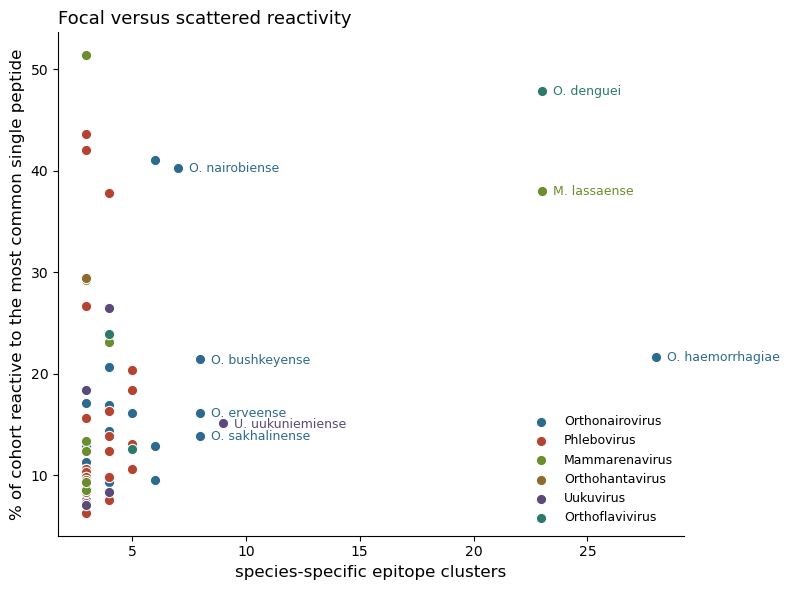

In [30]:
n_total = df.loc[df.cohort == 'SL', 'individual'].nunique()


def short(name):
    parts = str(name).split()
    return f"{parts[0][0]}. {' '.join(parts[1:])}" if len(parts) > 1 else name

h = hits.copy(); h['cluster'] = h.index.map(labels)
r = df[df.reactive & df.peptide.isin(h.index)].copy()
r['species'] = r.peptide.map(h['species'])

per_pep = r.groupby(['species','peptide']).individual.nunique()
prev = pd.DataFrame({
    'max_pep_prev': 100*per_pep.groupby('species').max()/n_total,      # best single peptide
    'species_prev': 100*r.groupby('species').individual.nunique()/n_total,
})

pl = (comp.merge(prev, left_on='species', right_index=True)
          .query('genus in @top_gen and clusters_specific >= 3'))

fig, ax = plt.subplots(figsize=(8, 6))
for gen in top_gen:
    v = pl[pl.genus == gen]
    ax.scatter(v.clusters_specific, v.max_pep_prev, s=55, color=HI[gen],
               edgecolor='white', lw=.8, label=gen, zorder=3)

for _, r_ in pl.nlargest(8, 'clusters_specific').iterrows():
    ax.annotate(short(r_.species), (r_.clusters_specific, r_.max_pep_prev),
                fontsize=9, color=HI[r_.genus], xytext=(8, -3),
                textcoords='offset points')

ax.set_xlabel('species-specific epitope clusters', fontsize=12)
ax.set_ylabel('% of cohort reactive to the most common single peptide', fontsize=12)
ax.set_title('Focal versus scattered reactivity', fontsize=13, loc='left')
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout()
pl[['genus','species','clusters_specific','max_pep_prev','species_prev']].round(1)

In [31]:
pl.nlargest(10, 'max_pep_prev')[['genus','species','clusters_specific',
                                 'max_pep_prev','species_prev']].round(1)

# and the actual peptide behind the top one
top_sp = pl.nlargest(1, 'max_pep_prev').species.iloc[0]
pk = h[h.species == top_sp]
pp = r[r.peptide.isin(pk.index)].groupby('peptide').individual.nunique().nlargest(3)
print(top_sp); print(pp)
print(hits.loc[pp.index, ['protein_std','accession','sequence']].to_string())

Mammarenavirus choriomeningitidis
peptide
ABI96821.1|protein|Mammarenavirus_choriomeningitidis|?|?|?|?|L|CH-5692|tile_3                                                       204
AIW66623.1|glycoprotein|Mammarenavirus_choriomeningitidis|Makokou|Mus_musculus_domesticus|Gabon:_Makokou|06-Jun-2012|S|?|tile_14     84
WDY78991.1|precursor|Mammarenavirus_choriomeningitidis|KS22-098_L5719|Mus_musculus_domesticus|Germany|2022|S|?|tile_14               72
Name: individual, dtype: int64
                                                                                                                                   protein_std   accession                                        sequence
peptide                                                                                                                                                                                                   
ABI96821.1|protein|Mammarenavirus_choriomeningitidis|?|?|?|?|L|CH-5692|tile_3                                    

In [34]:
pid = 'AIW66623.1|glycoprotein|Mammarenavirus_choriomeningitidis|Makokou|Mus_musculus_domesticus|Gabon:_Makokou|06-Jun-2012|S|?|tile_14'
cid = labels[pid]
print('cluster', cid, '— members:')
print(h[h.cluster == cid][['species','protein_std','accession']].to_string())

cluster 99 — members:
                                                                                                                                                                                               species    protein_std    accession
peptide                                                                                                                                                                                                                           
ADD60472.1|precursor|Mammarenavirus_bearense|?|Neotoma_macrotis|USA|Jan-2000|S|AV_B0300052|tile_13                                                                             Mammarenavirus bearense   glycoprotein   ADD60472.1
ADX32840.1|precursor|Menekre_virus|?|Hylomyscus_sp.|Cote_d'Ivoire:_Menekre-_Prefecture_de_Gagnoa|Nov-2005|S|CIV1227|tile_14                                                              Menekre virus   glycoprotein   ADX32840.1
AFU54677.1|precursor|North_American_arenavirus|?|Neotoma_micropus_vouc

In [32]:
pid = 'ABI96821.1|protein|Mammarenavirus_choriomeningitidis|?|?|?|?|L|CH-5692|tile_3'
cid = labels[pid]
print('cluster', cid, '— members:')
print(h[h.cluster == cid][['species','protein_std','accession']].to_string())

# and its best match among LASV peptides
aln = make_aligner()
s0 = hits.loc[pid, 'sequence']
lasv = hits[hits.species == 'Mammarenavirus lassaense']
sc = {i: aln.score(s0, s)/min(aln.score(s0,s0), aln.score(s,s))
      for i, s in lasv.sequence.items()}
best = pd.Series(sc).nlargest(3)
print('\nbest LASV matches:'); print(best.round(3))
print(hits.loc[best.index, ['protein_std','sequence']].to_string())

cluster 97 — members:
                                                                                                                                      species protein_std   accession
peptide                                                                                                                                                              
ABI96821.1|protein|Mammarenavirus_choriomeningitidis|?|?|?|?|L|CH-5692|tile_3                               Mammarenavirus choriomeningitidis  polymerase  ABI96821.1
BBE37069.1|polymerase|Mammarenavirus_lassaense|Nig16-14|Homo_sapiens|Nigeria:_Ebonyi_State|2016|L|?|tile_3           Mammarenavirus lassaense  polymerase  BBE37069.1

best LASV matches:
BBE37069.1|polymerase|Mammarenavirus_lassaense|Nig16-14|Homo_sapiens|Nigeria:_Ebonyi_State|2016|L|?|tile_3                                             0.536
USR47367.1|polymerase|Mammarenavirus_lassaense|?|Lophuromys_sikapusi|Sierra_Leone:_Barlie|13-Jul-2019|L|L.sikapusi-wt/SLE/2019/Barlie-000

## OLD CODE

In [ ]:
sp_all = (comp.assign(pct_specific=lambda t: 100*t.clusters_specific/t.clusters_incl_shared)
              .query('genus in @top_gen'))
print(len(sp_all), 'species')


cl = hits.copy()
cl['cluster'] = cl.index.map(labels)
nsp = cl.groupby('cluster')['species'].nunique()

sp_cl = (cl.drop_duplicates(['species','cluster'])
           .assign(specific=lambda t: t.cluster.map(nsp) == 1))

comp = (sp_cl.groupby(['genus','species'])
             .agg(clusters_incl_shared=('cluster','nunique'),
                  clusters_specific=('specific','sum'))
             .reset_index())

sp_all = (comp.assign(pct_specific=lambda t: 100*t.clusters_specific/t.clusters_incl_shared)
              .query('genus in @top_gen'))

255 species


NameError: name 'sp_all' is not defined

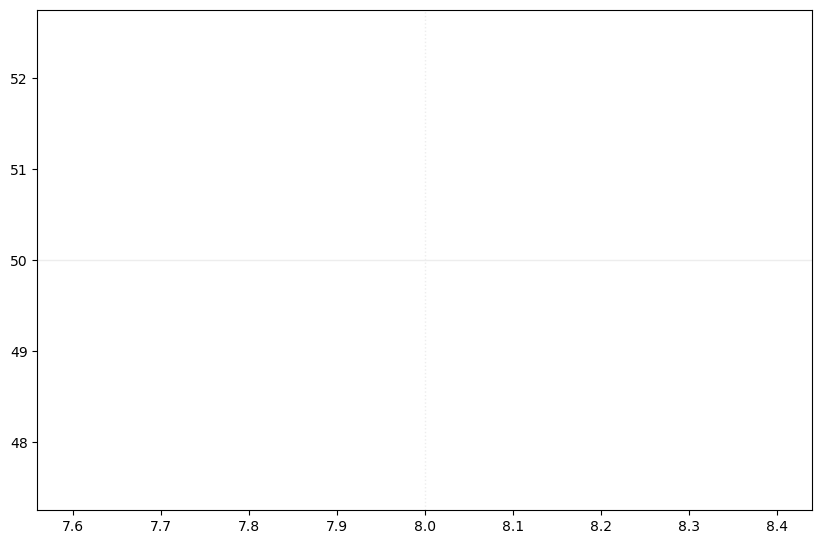

In [29]:
MIN_CL = 0     # shown
EMPH   = 8    # coloured + labelled

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.axhline(50, color='0.93', lw=1, zorder=0)
ax.axvline(EMPH, color='0.93', lw=1, ls=':', zorder=0)

MIN_CL = 0
sp_tab = sp_all[sp_all.clusters_incl_shared >= MIN_CL]

def short(name):
    parts = str(name).split()
    return f"{parts[0][0]}. {' '.join(parts[1:])}" if len(parts) > 1 else name

for gen in top_gen:
    v  = sp_tab[sp_tab.genus == gen]
    lo = v[v.clusters_incl_shared <  EMPH]
    hi = v[v.clusters_incl_shared >= EMPH]
    ax.scatter(lo.clusters_incl_shared, lo.pct_specific, s=34,
               color='0.82', edgecolor='white', lw=.6, zorder=2)
    ax.scatter(hi.clusters_incl_shared, hi.pct_specific, s=60, color=HI[gen],
               edgecolor='white', lw=.8, zorder=3)
    ax.scatter([], [], s=60, color=HI[gen], label=gen)      # legend entry regardless

for _, r in sp_tab[sp_tab.clusters_incl_shared >= EMPH].iterrows():
    dx, dy, ha = OFF.get(r.species, (8, -3, 'left'))
    ax.annotate(short(r.species), (r.clusters_incl_shared, r.pct_specific),
                fontsize=11, color=HI[r.genus], ha=ha,
                xytext=(dx, dy), textcoords='offset points', zorder=5)

ax.set_xlim(MIN_CL - 1, 40); ax.set_ylim(-3, 103)
ax.set_xlabel('independent epitope clusters', fontsize=12)
ax.set_ylabel('% of clusters containing only this species', fontsize=12)
ax.set_title('Species-specific versus cross-species epitope clusters', fontsize=13.5, pad=12)
ax.legend(frameon=False, fontsize=11, loc='lower right')
ax.spines[['top','right']].set_visible(False)

ax.tick_params(axis='both', labelsize=11)

plt.show()
plt.savefig('species_shared_vs_cross_clusters.svg', format='svg')
plt.tight_layout()

In [ ]:
print('species in comp (any genus):', comp.species.nunique())
print('species in sp_all (6 genera):', sp_all.species.nunique())
print('species in library:', lib.species.nunique())

species in comp (any genus): 348
species in sp_all (6 genera): 255
species in library: 465


In [ ]:
sp_tab.loc[sp_tab['genus'] == 'Phlebovirus'].sort_values(by='clusters_specific', ascending=False)

,genus,species,clusters_incl_shared,clusters_specific,pct_specific
254,Phlebovirus,Phlebovirus limboense,8,5,62.500000
235,Phlebovirus,Phlebovirus candiruense,8,5,62.500000
229,Phlebovirus,Phlebovirus baishanense,6,5,83.333333
246,Phlebovirus,Phlebovirus gloriaense,5,5,100.000000
279,Phlebovirus,Phlebovirus toroense,5,4,80.000000
...,...,...,...,...,...
234,Phlebovirus,Phlebovirus campanaense,1,0,0.000000
273,Phlebovirus,Phlebovirus saloboense,1,0,0.000000
260,Phlebovirus,Phlebovirus mungubaense,1,0,0.000000
262,Phlebovirus,Phlebovirus niqueense,1,0,0.000000


In [ ]:
sp_tab.describe()

,clusters_incl_shared,clusters_specific,pct_specific
count,255.000000,255.000000,255.000000
mean,3.258824,2.047059,60.869018
std,3.685958,2.957331,37.122753
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,33.333333
50%,3.000000,1.000000,66.666667
75%,4.000000,3.000000,100.000000
max,35.000000,28.000000,100.000000


In [ ]:
comp.head(10)

,genus,species,clusters_incl_shared,clusters_specific
0,Actinovirus,Actinovirus bernense,2,2
1,Actinovirus,Actinovirus triacanthodis,3,3
2,Agnathovirus,Agnathovirus eptatreti,2,2
3,Alphavirus,Alphavirus chikungunya,2,2
4,Antennavirus,Antennavirus hirsutum,4,4
5,Antennavirus,Antennavirus salmonis,2,2
6,Antennavirus,Antennavirus striale,4,3
7,Arenavirus,Arenavirus sp.,7,4
8,Arenavirus,Gbagroube virus,2,0
9,Arenavirus,Menekre virus,2,0


In [ ]:
cl = hits.copy(); cl['cluster'] = cl.index.map(labels)
nsp = cl.groupby('cluster')['species'].nunique()

sp_cl = (cl.drop_duplicates(['species','cluster'])
           .assign(specific=lambda t: t.cluster.map(nsp) == 1))

comp = (sp_cl.groupby(['genus','species'])
             .agg(clusters_incl_shared=('cluster','nunique'),
                  clusters_specific=('specific','sum'))
             .reset_index())

rows = []
for gen in top_gen:
    v = comp[comp.genus == gen]
    distinct = g.loc[gen, 'n_epitopes']                 # genus distinct clusters
    top_incl = v.nlargest(1, 'clusters_incl_shared').iloc[0]
    top_spec = v.nlargest(1, 'clusters_specific').iloc[0]
    rows.append({'genus': gen, 'n_species': len(v), 'distinct_clusters': distinct,
                 'top_species': top_incl.species,
                 'pct_incl_shared': round(100*top_incl.clusters_incl_shared/distinct, 1),
                 'pct_specific':    round(100*top_spec.clusters_specific/distinct, 1)})
pd.DataFrame(rows).sort_values('pct_specific', ascending=False)

,genus,n_species,distinct_clusters,top_species,pct_incl_shared,pct_specific
5,Orthoflavivirus,5,35,Orthoflavivirus denguei,71.4,65.7
2,Mammarenavirus,49,124,Mammarenavirus lassaense,28.2,18.5
4,Uukuvirus,23,50,Uukuvirus uukuniemiense,18.0,18.0
0,Orthonairovirus,53,199,Orthonairovirus haemorrhagiae,16.6,14.1
3,Orthohantavirus,50,60,Orthohantavirus andesense,10.0,5.0
1,Phlebovirus,75,174,Phlebovirus candiruense,4.6,2.9


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

order = (comp[comp.genus.isin(top_gen)].groupby('genus').species.nunique()
           .sort_values().index)

rows = []
for gen in order:
    v = (comp[comp.genus == gen]
           .sort_values('clusters_specific', ascending=False))
    distinct = g.loc[gen, 'n_epitopes']
    cum = np.cumsum(v.clusters_specific.to_numpy()) / distinct * 100
    ax.plot(np.arange(1, len(cum)+1), cum, marker='o', ms=4, lw=2,
            color=HI[gen], label=f'{gen} ({len(v)} species)')
    rows.append({'genus': gen, 'n_species': len(v),
                 'distinct_clusters': distinct,
                 'top_species': v.species.iloc[0],
                 'top_pct': round(cum[0], 1),
                 'pct_species_attributable': round(cum[-1], 1)})

ax.axhline(50, color='0.9', lw=1, zorder=0)
ax.set_ylim(0, 100)
ax.set_xlabel('species, ranked by species-specific epitope clusters', fontsize=11)
ax.set_ylabel("cumulative % of genus's epitope clusters", fontsize=11)
ax.set_title('Genera reactivity is either concentrated in one species or spread across many'',
             fontsize=12.5, loc='left')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

pd.DataFrame(rows)

SyntaxError: unterminated string literal (detected at line 24) (2153585212.py, line 24)

In [ ]:
(comp[comp.clusters_specific == 0]
   .merge(s[['species','n_peptides']], on='species', how='left')
   .groupby('genus').n_peptides.describe()[['count','50%','max']].loc[top_gen])

,count,50%,max
genus,,,
Orthonairovirus,2.0,2.5,3.0
Phlebovirus,1.0,2.0,2.0
Mammarenavirus,2.0,2.5,3.0
Orthohantavirus,15.0,2.0,6.0
Uukuvirus,1.0,2.0,2.0
Orthoflavivirus,1.0,3.0,3.0


,genus,n_species,top_species_pct,species_for_50pct
0,Orthoflavivirus,4,66,1
1,Uukuvirus,15,20,5
2,Mammarenavirus,28,22,6
3,Orthohantavirus,34,6,13
4,Orthonairovirus,45,15,12
5,Phlebovirus,60,4,20


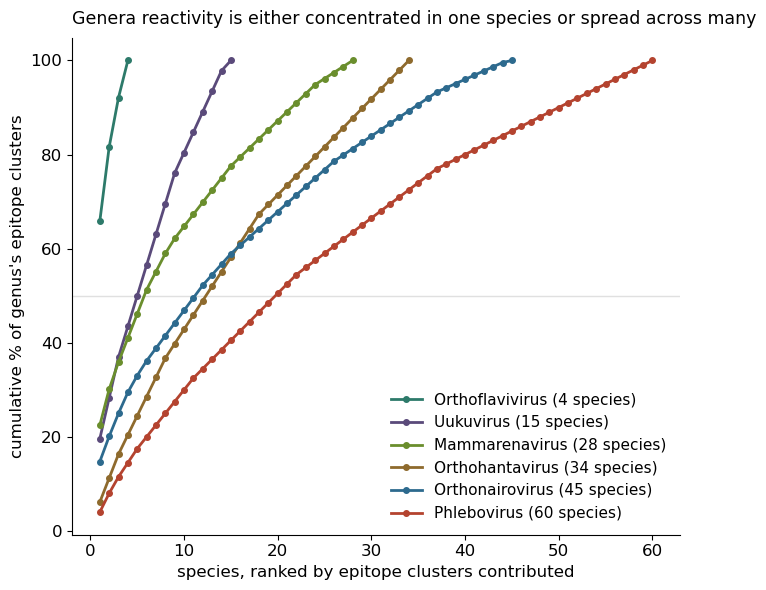

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

rows = []

order = (s[s.genus.isin(top_gen)].groupby('genus').species.nunique()
           .sort_values().index)          # fewest species first

for gen in order:
    v = s[s.genus == gen].sort_values('n_epitopes', ascending=False).n_epitopes.to_numpy()
    if len(v) < 2: continue
    cum = np.cumsum(v)/v.sum()*100
    ax.plot(np.arange(1, len(v)+1), cum, marker='o', ms=4, lw=2,
            color=HI[gen], label=f'{gen} ({len(v)} species)')
    rows.append({'genus': gen, 'n_species': len(v),
                 'top_species_pct': round(cum[0]),
                 'species_for_50pct': int(np.searchsorted(cum, 50) + 1)})

ax.axhline(50, color='0.88', lw=1, zorder=0)

ax.set_xlabel('species, ranked by epitope clusters contributed', fontsize=12)
ax.set_ylabel("cumulative % of genus's epitope clusters", fontsize=12)
ax.set_title('Genera reactivity is either concentrated in one species or spread across many',
             fontsize=12.5, loc='left', pad=10)

ax.legend(frameon=False, fontsize=11, loc='lower right')
ax.spines[['top','right']].set_visible(False)

ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()


pd.DataFrame(rows)

In [ ]:
cl = hits.copy(); cl['cluster'] = cl.index.map(labels)
lasv_cl = set(cl.loc[cl.species == 'Mammarenavirus lassaense', 'cluster'])
shared  = cl[cl.cluster.isin(lasv_cl) & (cl.species != 'Mammarenavirus lassaense')]
print(f"{len(lasv_cl)} LASV clusters, {shared.cluster.nunique()} shared with other species")
print(shared.groupby('species').cluster.nunique().sort_values(ascending=False).head(10))
print(shared.groupby('protein_std').cluster.nunique())

35 LASV clusters, 12 shared with other species
species
Mammarenavirus lunaense              4
Mammarenavirus kwanzaense            3
Mammarenavirus wenzhouense           3
Mammarenavirus caliense              2
Mammarenavirus mopeiaense            2
Mammarenavirus praomyidis            2
Mammarenavirus choriomeningitidis    2
Gbagroube virus                      1
Mammarenavirus loeiense              1
Mammarenavirus kitaleense            1
Name: cluster, dtype: int64
protein_std
glycoprotein     3
nucleoprotein    3
polymerase       7
Name: cluster, dtype: int64


## table for reactive peptides per species and epitopes per responder

In [ ]:
per_ind = (react.groupby(['species','individual'])['cluster'].nunique()
                .groupby('species').mean().rename('epitopes_per_responder'))

tab = (react[react.genus.isin(top_gen)]
       .groupby(['genus','species'])
       .agg(n_peptides=('peptide','nunique'),
            n_epitopes=('cluster','nunique'),
            n_individuals=('individual','nunique'))
       .join(per_ind)
       .assign(pct_cohort=lambda t: (100*t.n_individuals/n_total).round(0),
               collapse=lambda t: (100*(1 - t.n_epitopes/t.n_peptides)).round(0),
               epitopes_per_responder=lambda t: t.epitopes_per_responder.round(2))
       .reset_index()
       .sort_values(['genus','n_epitopes'], ascending=[True, False]))

tab.to_csv('supp_species_table.csv', index=False)
tab.head(40)

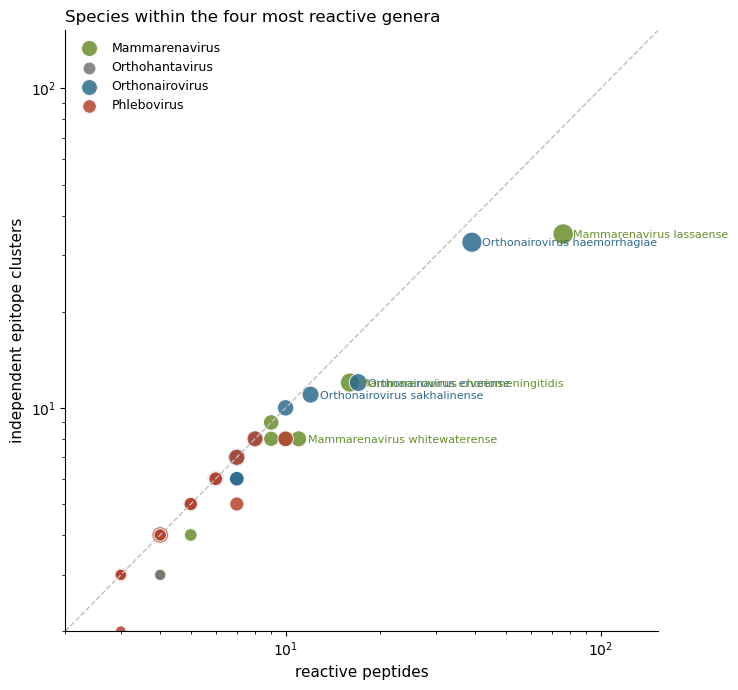

In [ ]:
react['species'] = react.peptide.map(hits['species'])
GEN = ['Phlebovirus','Orthonairovirus','Mammarenavirus','Orthohantavirus']

s = (react[react.genus.isin(GEN)]
     .groupby(['genus','species'])
     .agg(n_peptides=('peptide','nunique'), n_epitopes=('cluster','nunique'),
          n_individuals=('individual','nunique')).reset_index())
s['collapse'] = (100*(1 - s.n_epitopes/s.n_peptides)).round(0)
s = s[s.n_peptides >= 3]

GEN_COLOR = {'Phlebovirus':'#b4432f','Orthonairovirus':'#2d6a8e',
             'Mammarenavirus':'#6a8e2d','Orthohantavirus':'0.45'}

fig, ax = plt.subplots(figsize=(7.5, 7))
lim = [2, s.n_peptides.max()*2]
ax.plot(lim, lim, ls='--', color='0.75', lw=1)
for gen, grp in s.groupby('genus'):
    ax.scatter(grp.n_peptides, grp.n_epitopes, s=20 + 2.5*grp.n_individuals/5,
               color=GEN_COLOR[gen], edgecolor='white', lw=.7, alpha=.85, label=gen)

for _, row in s.nlargest(6, 'n_peptides').iterrows():
    ax.annotate(row.species, (row.n_peptides, row.n_epitopes), fontsize=8,
                color=GEN_COLOR[row.genus], xytext=(7, -3), textcoords='offset points')

ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('reactive peptides', fontsize=11)
ax.set_ylabel('independent epitope clusters', fontsize=11)
ax.set_title('Species within the four most reactive genera', fontsize=12, loc='left')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

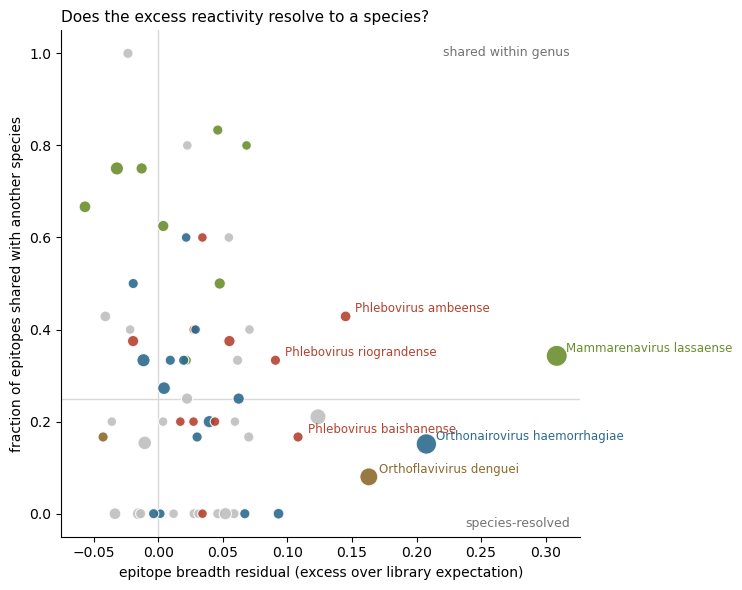

In [ ]:
# panel B: does the excess resolve to a species?
sub = ds.join(hits.drop_duplicates('species').set_index('species')['genus'])
sub = sub[(sub.n_epitopes >= 5)]           # fractions on <5 epitopes are noise

GEN_COLOR = {'Phlebovirus':'#b4432f', 'Orthonairovirus':'#2d6a8e',
             'Mammarenavirus':'#6a8e2d', 'Orthoflavivirus':'#8e6a2d'}
col = sub.genus.map(GEN_COLOR).fillna('0.75')

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.axhline(0.25, color='0.85', lw=1, zorder=0)
ax.axvline(0, color='0.85', lw=1, zorder=0)

ax.scatter(sub.resid_epitope, sub.cross_species_frac,
           s=18 + 6*sub.n_epitopes.clip(upper=40), c=col,
           edgecolor='white', lw=.8, alpha=.9, zorder=3)

LAB = ['Mammarenavirus lassaense','Orthonairovirus haemorrhagiae',
       'Orthoflavivirus denguei','Phlebovirus ambeense',
       'Phlebovirus riograndense','Phlebovirus baishanense']
for s in LAB:
    if s in sub.index:
        ax.annotate(s, (sub.resid_epitope[s], sub.cross_species_frac[s]),
                    fontsize=8.5, xytext=(7, 3), textcoords='offset points',
                    color=col[s] if col[s] != '0.75' else '0.4')

ax.set_xlabel('epitope breadth residual (excess over library expectation)', fontsize=10)
ax.set_ylabel('fraction of epitopes shared with another species', fontsize=10)
ax.set_title('Does the excess reactivity resolve to a species?', fontsize=11, loc='left')
ax.spines[['top','right']].set_visible(False)

ax.annotate('species-resolved', (0.98, 0.02), xycoords='axes fraction',
            ha='right', fontsize=9, color='0.45')
ax.annotate('shared within genus', (0.98, 0.95), xycoords='axes fraction',
            ha='right', fontsize=9, color='0.45')
plt.tight_layout()

In [ ]:
for cut in (100, 500, 1000):
    dd = ds[ds.lib_peptides >= cut]
    xx, yy = np.log10(dd.lib_peptides), np.log10(dd.mean_epitopes)
    bb, aa = np.polyfit(xx, yy, 1)
    res = (yy - (aa + bb*xx))
    print(f'cut={cut:5}  n={len(dd):3}  slope={bb:.3f}  ',
          res.reindex(['Mammarenavirus lassaense','Orthonairovirus haemorrhagiae',
                       'Orthoflavivirus denguei']).round(3).to_dict())

cut=  100  n=311  slope=0.247   {'Mammarenavirus lassaense': 0.309, 'Orthonairovirus haemorrhagiae': 0.208, 'Orthoflavivirus denguei': 0.163}
cut=  500  n= 15  slope=0.554   {'Mammarenavirus lassaense': 0.08, 'Orthonairovirus haemorrhagiae': 0.056, 'Orthoflavivirus denguei': 0.039}
cut= 1000  n=  7  slope=0.674   {'Mammarenavirus lassaense': 0.045, 'Orthonairovirus haemorrhagiae': 0.051, 'Orthoflavivirus denguei': 0.045}


In [ ]:
fl = ds.join(hits.drop_duplicates('species').set_index('species')['genus'])
fl[fl.genus == 'Orthoflavivirus'][['lib_peptides','mean_epitopes','n_epitopes']]

,lib_peptides,mean_epitopes,n_epitopes
species,,,
Chimeric Tick-borne encephalitis virus/Dengue virus 4,143,1.112676,3
Orthoflavivirus denguei,2050,2.890667,25
Orthoflavivirus flavi,366,1.180723,4
Orthoflavivirus kyasanurense,148,1.000000,1
Orthoflavivirus zikaense,512,1.276471,6


In [ ]:
react = df[df.reactive].copy()
react['cluster'] = react.peptide.map(labels)
react['genus']   = react.peptide.map(hits['genus'])

#averages over reactive individuals for that genus
obs   = (react.groupby(['genus','individual'])['cluster'].nunique()
         .groupby('genus').mean().rename('mean_epitopes'))

#average over total cohort so rare genuses will be less weighted
"""n_total = df.loc[df.cohort == 'SL', 'individual'].nunique()
obs = (react.groupby(['genus','individual'])['cluster'].nunique()
            .groupby('genus').sum() / n_total).rename('mean_epitopes')"""


libn  = lib.groupby('genus').size().rename('lib_peptides')
n_ind = react.groupby('genus')['individual'].nunique().rename('n_individuals')

In [ ]:
MIN_LIB = 150   # ignore sparsely represented genera
MIN_IND = 80 #minimum individuals which must have at least one reactive peptide for that genus for the genus to appear in the plot (approx `10% of cohort`)

n_ind = r.groupby('genus')['individual'].nunique().rename('n_individuals')
d = pd.concat([obs, libn, n_ind], axis=1).dropna()
d = d[(d.mean_epitopes > 0) & (d.lib_peptides >= MIN_LIB) & (d.n_individuals >= MIN_IND)]

x, y = np.log10(d.lib_peptides), np.log10(d.mean_epitopes)
b, a = np.polyfit(x, y, 1)
d['residual'] = y - (a + b * x)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x, y, s=30, color='0.65')
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, a + b*xs, color='0.3', lw=1, ls='--')

for g in d[d.residual > 0].sort_values('residual', ascending=False).head(3).index:
    ax.scatter(np.log10(d.lib_peptides[g]), np.log10(d.mean_epitopes[g]), 
               s=42, facecolor='none', edgecolor='0.25', lw=1.2)
    ax.annotate(g, (np.log10(d.lib_peptides[g]), np.log10(d.mean_epitopes[g])),
                fontsize=11, color='#b4432f', xytext=(+10, -3), textcoords='offset points')

for g in ['Reptarenavirus', 'Orthoflavivirus', 'Orthohantavirus', 'Uukuvirus']:
    if g in d.index:
        ax.scatter(np.log10(d.lib_peptides[g]), np.log10(d.mean_epitopes[g]),
                   s=42, facecolor='none', edgecolor='0.25', lw=1.2)
        ax.annotate(g, (np.log10(d.lib_peptides[g]), np.log10(d.mean_epitopes[g])),
                    fontsize=10, xytext=(5, -10), textcoords='offset points')



ax.set_xlabel('log10 library peptides', fontsize=12); ax.set_ylabel('log10 mean epitopes / individual', fontsize=12)
ax.set_title('Independent epitope breadth vs library representation', fontsize=13)

ax.tick_params(axis='x' ,labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('peps_vs_epitope_breadth_genera.svg', format='svg')
plt.show()

KeyError: 'genus'

In [ ]:
nsp_lib = lib.groupby('genus').species.nunique().rename('n_species_lib')
dd = full[full.lib_peptides >= 500].join(nsp_lib)

import statsmodels.api as sm   # or use np.linalg.lstsq
X = sm.add_constant(np.column_stack([np.log10(dd.lib_peptides),
                                     np.log10(dd.n_species_lib)]))
m = sm.OLS(np.log10(dd.mean_epitopes), X).fit()
print(m.summary().tables[1])
dd['resid2'] = m.resid
print(dd.resid2.sort_values(ascending=False).round(3).head(8))

NameError: name 'full' is not defined

In [ ]:
d.sort_values(by=['residual','mean_epitopes'], ascending=False).round(2)

,mean_epitopes,lib_peptides,n_individuals,residual
genus,,,,
Phlebovirus,18.33,13300,397.0,0.27
Orthonairovirus,20.24,17177,397.0,0.25
Mammarenavirus,16.35,18569,397.0,0.14
Reptillovirus,1.14,160,104.0,0.13
Tanzavirus,1.10,155,101.0,0.12
Innmovirus,1.16,181,131.0,0.11
Cuevavirus,1.27,216,181.0,0.10
Ocetevirus,1.36,255,199.0,0.09
Thamnovirus,1.10,186,102.0,0.08


## multiepitope table - using independent epitope clusters as exposure criterion

In [ ]:
def multiepitope_table(df, hits, labels, level='species', reactive_col='reactive'):
    r = df[df[reactive_col]].copy()
    r['cluster'] = r.peptide.map(labels)
    if level not in r.columns:
        r[level] = r.peptide.map(hits[level])
    r = r.dropna(subset=[level, 'cluster'])

    per = (r.groupby([level, 'individual'])['cluster'].nunique()
             .rename('n_epitopes').reset_index())

    return (per.assign(multi=lambda d: d.n_epitopes >= 2)
               .groupby(level)
               .agg(n_individuals=('individual', 'nunique'),
                    n_multi=('multi', 'sum'),
                    max_epitopes=('n_epitopes', 'max'))
               .assign(n_single=lambda d: d.n_individuals - d.n_multi,
                       pct_multi=lambda d: 100 * d.n_multi / d.n_individuals)
               .sort_values('n_multi', ascending=False))


tab = multiepitope_table(df, hits, labels)
tab.head(10)

,n_individuals,n_multi,max_epitopes,n_single,pct_multi
species,,,,,
Mammarenavirus lassaense,393,373,14,20,94.910941
Orthonairovirus haemorrhagiae,376,318,10,58,84.574468
Orthoflavivirus denguei,375,291,9,84,77.600000
Nairoviridae sp.,331,228,6,103,68.882175
Mammarenavirus choriomeningitidis,338,199,6,139,58.875740
Orthonairovirus erveense,288,138,5,150,47.916667
unidentified Reptarenavirus,264,134,4,130,50.757576
Orthonairovirus nairobiense,281,118,4,163,41.992883
Mammarenavirus lunaense,244,114,4,130,46.721311


<Axes: title={'left': 'Reactivity to multiple independent epitopes per individual'}, xlabel='individuals with reactive peptides'>

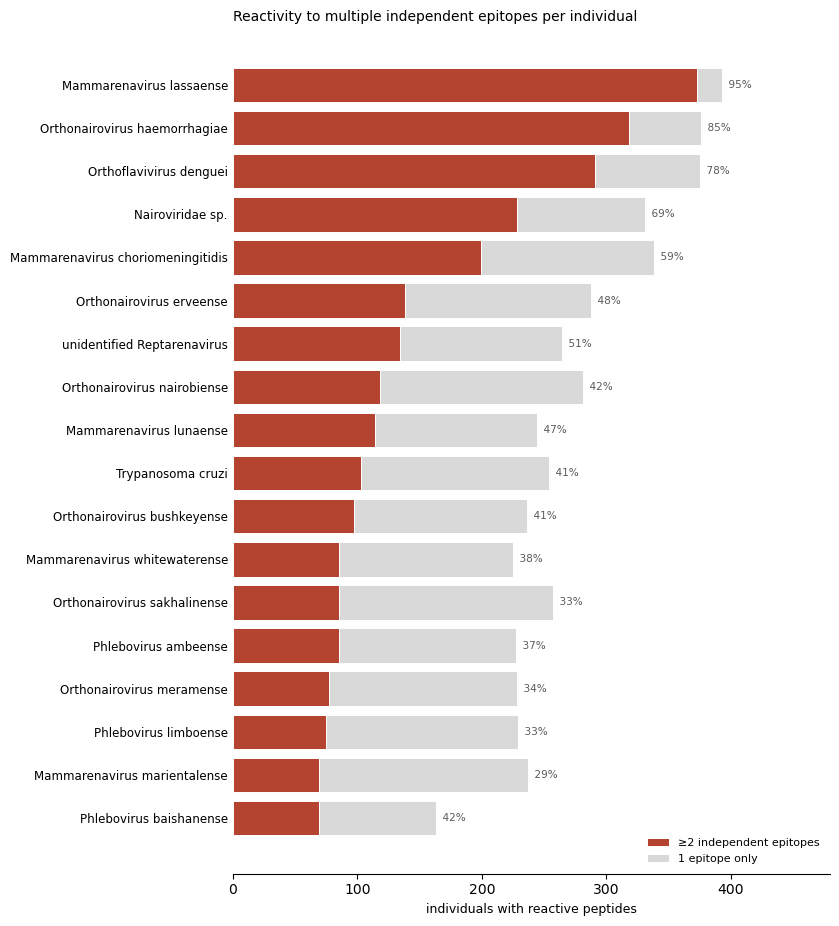

In [ ]:
def plot_multiepitope(tab, top_n=18, ax=None, min_individuals=1,
                      colors=('#b4432f', '#d9d9d9')):
    t = tab[tab.n_individuals >= min_individuals].head(top_n)[::-1]
    if ax is None:
        _, ax = plt.subplots(figsize=(8.5, .42 * len(t) + 1.8))
    ax.barh(t.index, t.n_multi, color=colors[0], label='≥2 independent epitopes',
            edgecolor='white', lw=.7)
    ax.barh(t.index, t.n_single, left=t.n_multi, color=colors[1],
            label='1 epitope only', edgecolor='white', lw=.7)
    for i, (sp, row) in enumerate(t.iterrows()):
        ax.annotate(f'  {row.pct_multi:.0f}%', (row.n_individuals, i),
                    va='center', fontsize=7.5, color='0.35')
    ax.set_xlabel('individuals with reactive peptides', fontsize=9)
    ax.set_xlim(0, t.n_individuals.max() * 1.22)
    ax.legend(frameon=False, fontsize=8, loc='lower right')
    ax.spines[['top','right','left']].set_visible(False)
    ax.tick_params(axis='y', length=0, labelsize=8.5)
    ax.set_title('Reactivity to multiple independent epitopes per individual',
                 fontsize=10, loc='left')
    plt.tight_layout()
    return ax


plot_multiepitope(tab, top_n=18)

<Axes: title={'left': 'Reactivity to multiple independent epitopes per individual'}, xlabel='individuals with reactive peptides'>

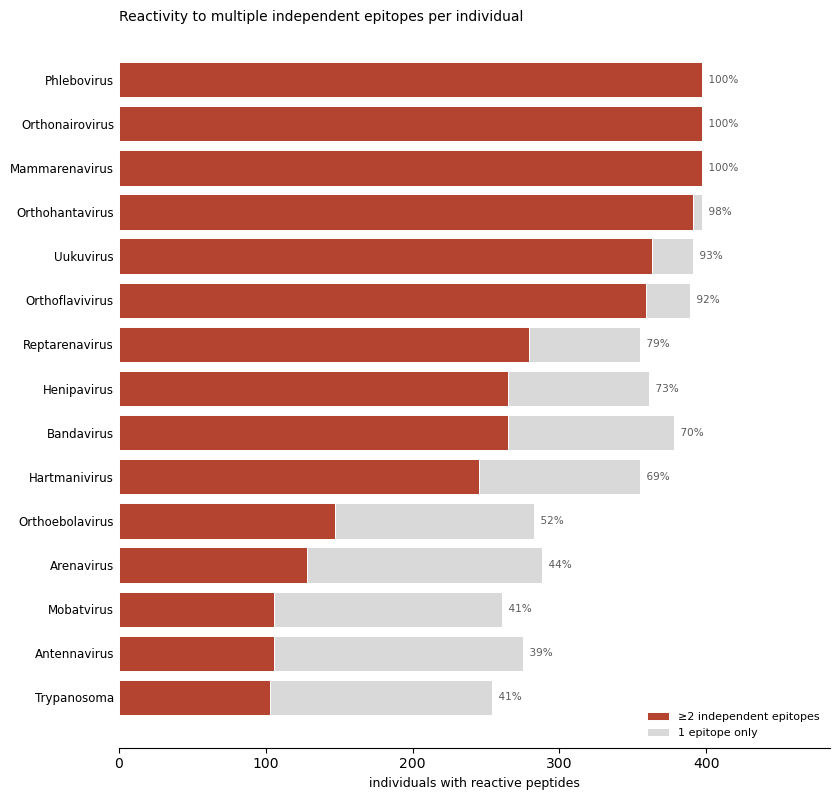

In [ ]:
if 'genus' not in df.columns:
    df['genus'] = df.peptide.map(hits['genus'])

tab_g = multiepitope_table(df, hits, labels, level='genus')
plot_multiepitope(tab_g, top_n=15)

In [ ]:
size = hits.groupby(hits.index.map(labels)).size()
print(size.value_counts().head())
print(f"{(size==1).mean():.0%} of clusters are singletons")
print(f"{len(hits)} peptides -> {len(size)} clusters")

1    748
2    133
3     37
4      9
5      5
Name: count, dtype: int64
79% of clusters are singletons
1287 peptides -> 945 clusters


In [ ]:
fl = hits[hits.genus == 'Orthoflavivirus']
cl = hits.copy(); cl['cluster'] = cl.index.map(labels)
nsp = cl.groupby('cluster')['species'].nunique()

fr = df[df.reactive & df.peptide.isin(fl.index)].copy()
fr['cluster'] = fr.peptide.map(labels)
fr['species'] = fr.peptide.map(hits['species'])
fr['specific'] = fr.cluster.map(nsp) == 1

# per species: how much of its epitope breadth is its own?
print(fr.drop_duplicates(['species','cluster'])
        .groupby('species')['specific'].agg(['sum','count'])
        .assign(pct_specific=lambda t: (100*t['sum']/t['count']).round(0)))

# per individual: does anyone have a DENV-only epitope?
denv = fr[fr.species.str.contains('denguei', na=False)]
print('\nindividuals with >=1 DENV-specific epitope:',
      denv[denv.specific].individual.nunique(), 'of', denv.individual.nunique())

                                                    sum  count  pct_specific
species                                                                     
Chimeric Tick-borne encephalitis virus/Dengue v...    0      3           0.0
Orthoflavivirus denguei                              23     25          92.0
Orthoflavivirus flavi                                 4      4         100.0
Orthoflavivirus kyasanurense                          0      1           0.0
Orthoflavivirus zikaense                              5      6          83.0

individuals with >=1 DENV-specific epitope: 369 of 375


In [ ]:
r['species'] = r.peptide.map(hits['species'])

obs_s = (r.groupby(['species','individual'])['cluster'].nunique()
           .groupby('species').mean().rename('mean_epitopes'))
pep_s = (r.groupby(['species','individual'])['peptide'].nunique()
           .groupby('species').mean().rename('mean_peptides'))
lib_s = lib.groupby('species').size().rename('lib_peptides')
ind_s = r.groupby('species')['individual'].nunique().rename('n_individuals')

ds = pd.concat([obs_s, pep_s, lib_s, ind_s], axis=1).dropna()
ds = ds[(ds.lib_peptides >= 100) & (ds.n_individuals >= 20)]

for col, name in [('mean_peptides','resid_peptide'), ('mean_epitopes','resid_epitope')]:
    xx, yy = np.log10(ds.lib_peptides), np.log10(ds[col])
    bb, aa = np.polyfit(xx, yy, 1)
    ds[name] = yy - (aa + bb*xx)

ds.sort_values('resid_epitope', ascending=False)[
    ['lib_peptides','mean_peptides','mean_epitopes','resid_peptide','resid_epitope']].round(3).head(20)

,lib_peptides,mean_peptides,mean_epitopes,resid_peptide,resid_epitope
species,,,,,
Mammarenavirus lassaense,4494,7.440,4.908,0.435,0.309
Orthonairovirus haemorrhagiae,2524,3.529,3.372,0.182,0.208
Orthoflavivirus denguei,2050,3.037,2.891,0.143,0.163
Phlebovirus ambeense,170,1.498,1.498,0.143,0.145
Nairoviridae sp.,1160,2.293,2.293,0.091,0.124
Phlebovirus baishanense,247,1.509,1.509,0.101,0.108
Uukuvirus dabieshanense,103,1.201,1.201,0.109,0.103
Orthonairovirus nairobiense,333,1.569,1.569,0.081,0.093
Phlebovirus riograndense,167,1.316,1.316,0.089,0.091


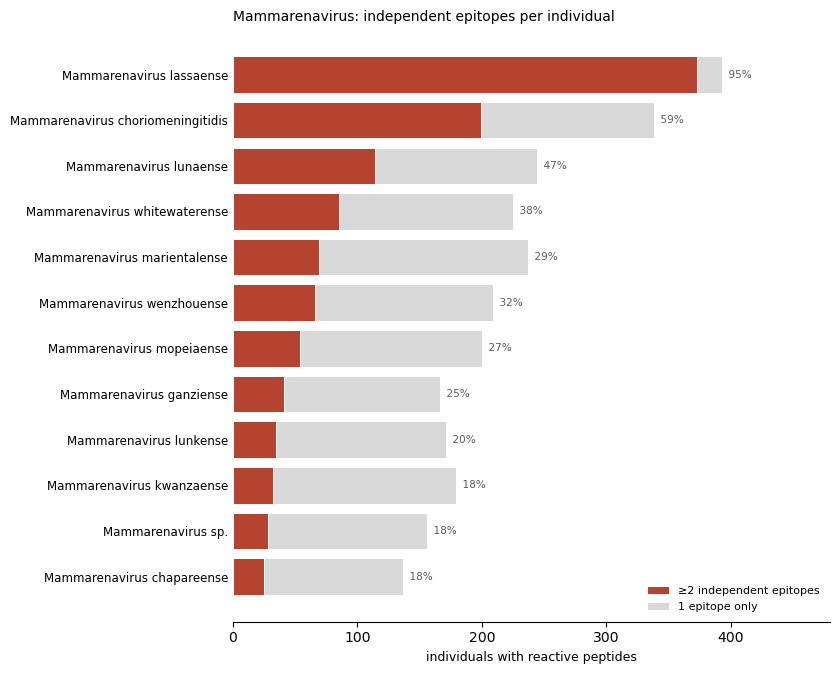

In [ ]:
def plot_species_in_genus(genus, df, hits, labels, top_n=12, min_individuals=20):
    peps = hits[hits.genus == genus].index
    sub  = df[df.peptide.isin(peps)]
    t    = multiepitope_table(sub, hits, labels, level='species')
    t    = t[t.n_individuals >= min_individuals]
    ax   = plot_multiepitope(t, top_n=top_n)
    ax.set_title(f'{genus}: independent epitopes per individual', fontsize=10, loc='left')
    return t

t_mam = plot_species_in_genus('Mammarenavirus', df, hits, labels)

## Cross-reactivity clusters

In [21]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def crossreactive_clusters(hits, labels, species, rank="species"):
    """Clusters containing `species` that also contain >=1 other species."""
    h = hits.copy()
    h["cluster"] = h.index.map(labels)
    target_cl = set(h.loc[h[rank] == species, "cluster"])
    sub = h[h.cluster.isin(target_cl)]
    multi = sub.groupby("cluster")[rank].nunique()
    return sub[sub.cluster.isin(multi[multi > 1].index)].sort_values(["cluster", rank])


cc = crossreactive_clusters(hits, labels, "Orthonairovirus haemorrhagiae")
print(cc.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
cc[["cluster", "species", "protein_std", "sequence"]].head(30)

cluster
456    3
534    3
12     2
49     2
547    2
Name: species, dtype: int64


,cluster,species,protein_std,sequence
peptide,,,,
WPS63666.1|precursor|Erve_virus|isolate=KS12-1272|Crocidura_russula|Germany:_North_Rhine-Westphalia-_Duisburg|2002|segment=M|strain=?|tile_40,12,Orthonairovirus erveense,glycoprotein,LPNEIITLHKVQGGEVDLMHVNKILTANSLCKLQSCTHGSPGDIQI
WPS63668.1|precursor|Erve_virus|isolate=KS17-1734|Crocidura_leucodon|Germany:_Thuringia-_Unstrut-Hainich-Kreis|2017|segment=M2|strain=?|tile_40,12,Orthonairovirus erveense,glycoprotein,LPSEIITLHKAQGGEVDLMHVNKILTANSLCKPQSCTHGSPGDIQI
XKB88840.1|precursor|Orthonairovirus_haemorrhagiae|isolate=CCHF/NIHPAK-37/2024|Homo_sapiens|Pakistan:_Punjab|12-Jul-2024|segment=M|strain=?|tile_57,12,Orthonairovirus haemorrhagiae,glycoprotein,LPPEIITLHPKIEEGFFDLMHVQRVLSASTVCKLQSCTHGVPGDLQ
XLQ26681.1|precursor|Orthonairovirus_haemorrhagiae|isolate=?|tick|China|1984|segment=M|strain=BA84021|tile_29,49,Orthonairovirus haemorrhagiae,glycoprotein,DVCDSSCELMIPKGTGDILVDCSGGQQHFLQNNLVDLGCPNIPLLG
XPD10970.1|glycoprotein|Orthonairovirus_haemorrhagiae|isolate=372-ARM-TI-2022|tick|Armenia|2022|segment=M|strain=?|tile_28,49,Orthonairovirus haemorrhagiae,glycoprotein,VKLSRGSEVVLDACDSSCEVMIPKGTGDILVDCSGGQQHFLKDNLI
XRL83237.1|glycoprotein|Wetland_virus|isolate=Tick_NMG38|Haemaphysalis_concinna|China|2023|segment=?|strain=?|tile_19,49,Wetland virus,glycoprotein,EVITCDKDCLAKIPSGRGDIQIDCPGGKQHYLETNVVDINCPGPER
WPS63658.1|polymerase|Erve_virus|isolate=KS17-1734|Crocidura_leucodon|Germany:_Thuringia-_Unstrut-Hainich-Kreis|2017|segment=L2|strain=?|tile_98,456,Orthonairovirus erveense,polymerase,SLLRTTNDDGLTNQHLKETVLNHALDSLSTMRSVDGEPLKGSSNLI
XQQ58340.1|polymerase|Orthonairovirus_haemorrhagiae|isolate=CCHFV_6_161|Hyalomma_anatolicum|Tajikistan|26-May-2023|segment=L|strain=?|tile_101,456,Orthonairovirus haemorrhagiae,polymerase,RNLLKTTSDDGLTNPHLKETILNVGLDCLTNMRNLDGKPINEGSNL
WAX26529.1|polymerase|Cencurut_virus|isolate=SM-37|Suncus_murinus|Singapore|25-Feb-2014|segment=L|strain=?|tile_99,456,Orthonairovirus sunci,polymerase,FSRSILGTTEDDGLTNPKLKEAILGTALDSLSTMRKIDGTLVEGSN


Orthonairovirus erveense                 SLLRTTNDDGLTNQHLKETVLNHALDSLSTMRSVDGEPLKGSSNLI  polymerase
Orthonairovirus haemorrhagiae            RNLLKTTSDDGLTNPHLKETILNVGLDCLTNMRNLDGKPINEGSNL  polymerase
Orthonairovirus sunci                    FSRSILGTTEDDGLTNPKLKEAILGTALDSLSTMRKIDGTLVEGSN  polymerase


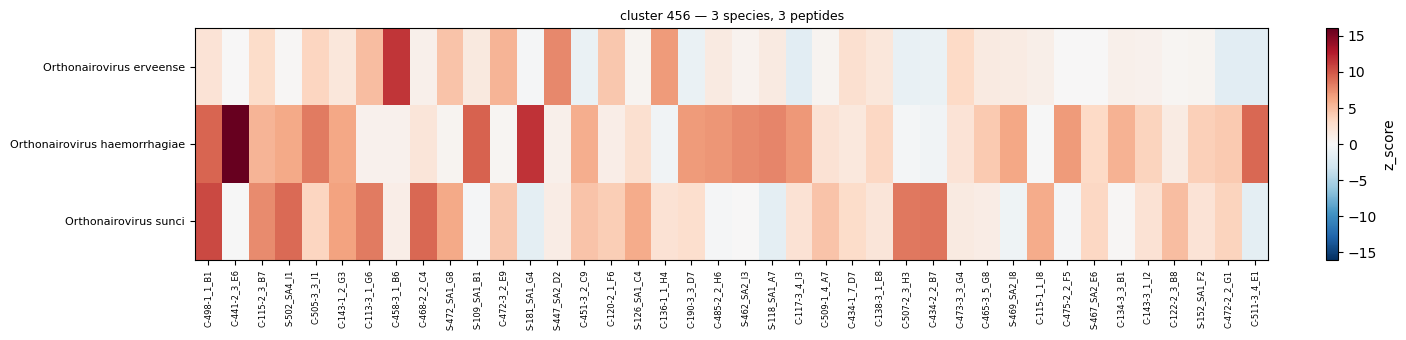

In [ ]:
def plot_cluster(cid, hits, labels, df, value="z_score", rank="species",
                 reactive_col="reactive", max_individuals=40, ax=None):
    h = hits.copy(); h["cluster"] = h.index.map(labels)
    peps = h[h.cluster == cid].sort_values(rank)

    m = (df[df.peptide.isin(peps.index)]
         .pivot_table(index="peptide", columns="individual", values=value))
    m = m.reindex(peps.index)

    hot = df[(df.peptide.isin(peps.index)) & (df[reactive_col])].individual.unique()
    m = m[[c for c in m.columns if c in set(hot)]]
    m = m[m.mean().sort_values(ascending=False).index[:max_individuals]]

    if ax is None:
        _, ax = plt.subplots(figsize=(max(5, .28 * m.shape[1] + 3), .5 * len(m) + 2))
    v = np.nanmax(np.abs(m.to_numpy())) if m.size else 1
    im = ax.imshow(m.to_numpy(), aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)

    ax.set_yticks(range(len(m)))
    ax.set_yticklabels([peps.loc[p, rank][:34] for p in m.index], fontsize=8)
    ax.set_xticks(range(m.shape[1]))
    ax.set_xticklabels(m.columns, rotation=90, fontsize=6)
    ax.set_title(f"cluster {cid} — {peps[rank].nunique()} species, {len(peps)} peptides",
                 fontsize=9)
    plt.colorbar(im, ax=ax, label=value, fraction=.025)
    return m, peps


cid = cc.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(cid, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

Orthonairovirus erveense                 LPNEIITLHKVQGGEVDLMHVNKILTANSLCKLQSCTHGSPGDIQI  glycoprotein
Orthonairovirus erveense                 LPSEIITLHKAQGGEVDLMHVNKILTANSLCKPQSCTHGSPGDIQI  glycoprotein
Orthonairovirus haemorrhagiae            LPPEIITLHPKIEEGFFDLMHVQRVLSASTVCKLQSCTHGVPGDLQ  glycoprotein


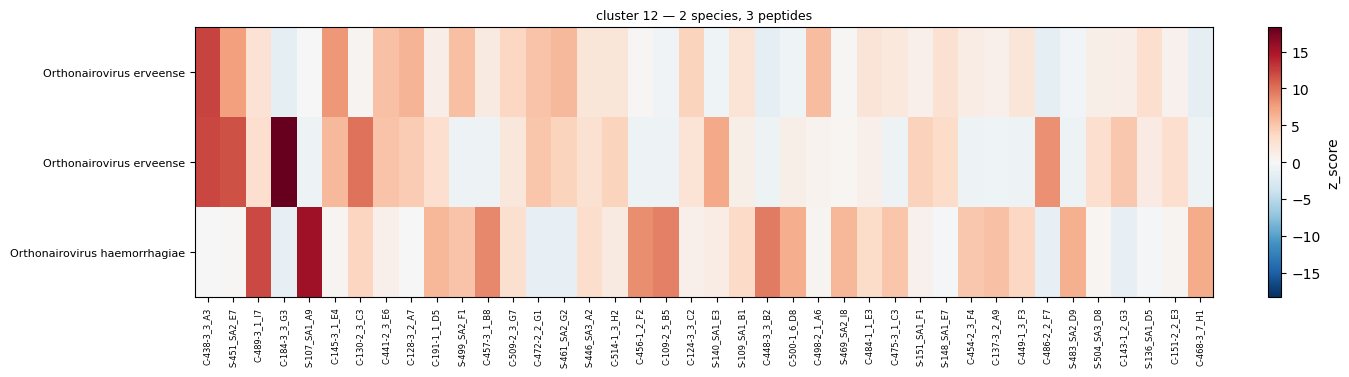

In [ ]:
m, peps = plot_cluster(12, hits, labels, df)
for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

cluster
152    6
212    5
696    4
40     3
669    3
150    3
461    3
276    3
565    3
97     2
Name: species, dtype: int64
Mammarenavirus caliense                  LKQLAKIPYCNYTKFWYINDTITGRHSLPQCWLVHNGSYLNETHFK  glycoprotein
Mammarenavirus kitaleense                SKFWYLNDTRNGKTSLPKCWLISNGSYLNETHFSDQIEQEADNMIT  glycoprotein
Mammarenavirus lassaense                 YWYLNNTVTGKSSLPKCWLVSNGSYLNETHFSEDIEQQADNMITEM  glycoprotein
Mammarenavirus lunaense                  FWYLNDTRNGKTSLPKCWKVSNNSYLNETQFSNEITEEANNMITEM  glycoprotein
Mammarenavirus lunkense                  YSKFWYLEHYKTGETSLPKCWLVSNGSYLNETHFSDEIEQEANNMI  glycoprotein
Mammarenavirus wenzhouense               LNNTRSNRTSLPRCWLVSNGSYLNETEFSSDIEQEANNLITEMLQR  glycoprotein


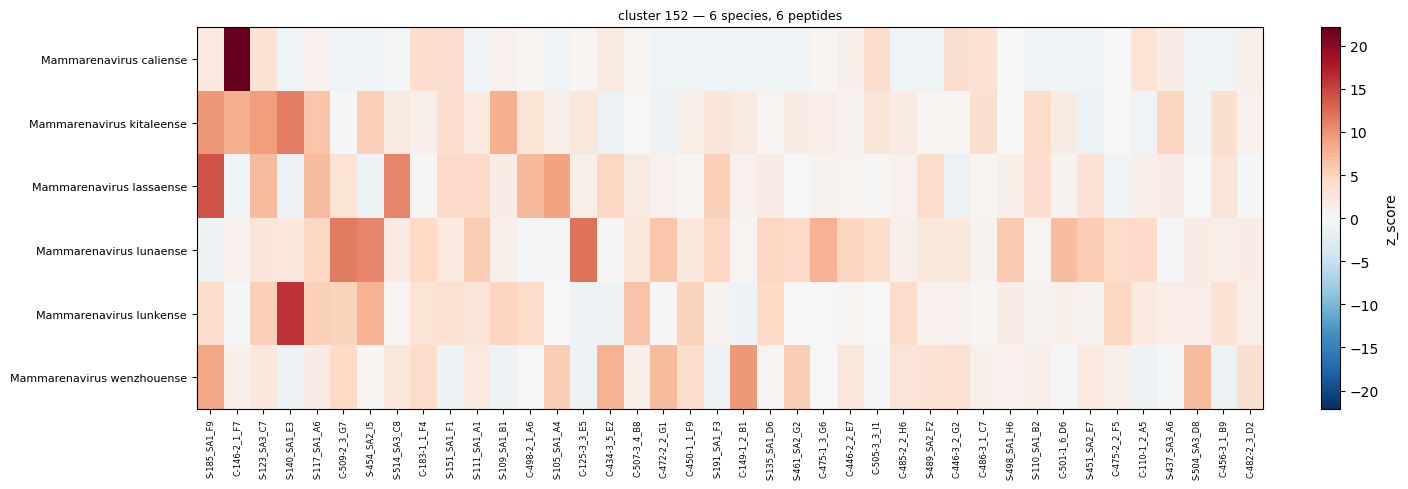

In [ ]:
lasv = crossreactive_clusters(hits, labels, "Mammarenavirus lassaense")
print(lasv.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
lasv[["cluster", "species", "protein_std", "sequence"]].head(10)

cid = lasv.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(cid, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

cluster
939    5
173    3
Name: species, dtype: int64
Hantaviridae sp.                         DSSFEDVNGIRKPKHLYVSMPNAQSSMKAEEITPGRYRTAVCGLFP  nucleoprotein
Huangpi virus                            SFDESGGVKVPRHLYVSLPTSQSSMKEDELTPGRYRTAVCGFFPGE  nucleoprotein
Orthohantavirus hantanense               DDSSFEDVNGIRKPKHLYVSLPNAQSSMKAEEITPGRYRTAVCGLY  nucleoprotein
Orthohantavirus jejuense                 DSSYVEVGSIRKPKHLYISLPSTQSSIKADELTPGRFRTLVCGLYP  nucleoprotein
Orthohantavirus mamorense                DSSFEEINGIRKPKHLYISMPTAQSTMKADEITPGRFRTIACGLFP  nucleoprotein


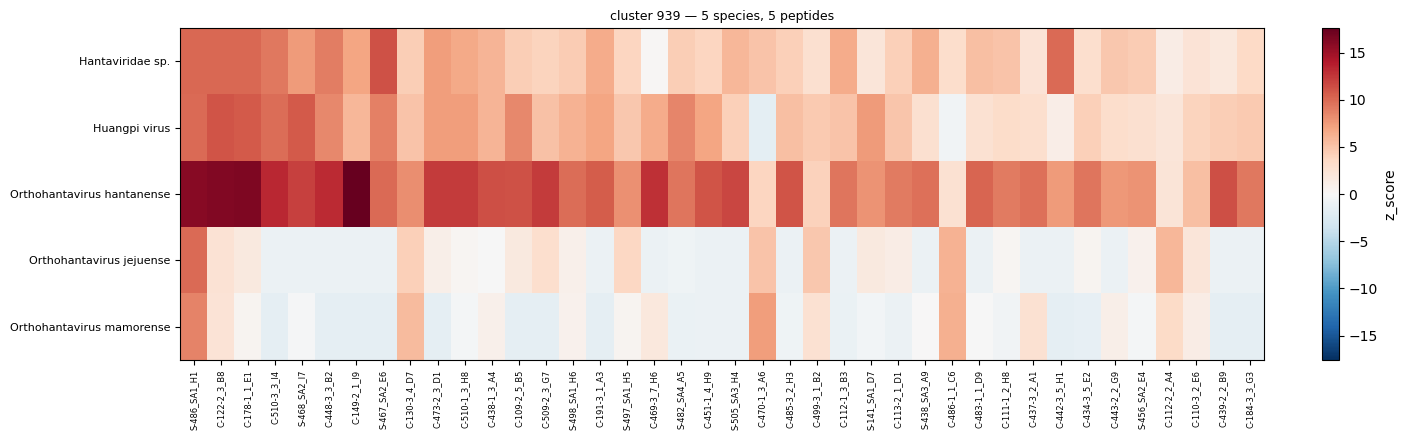

In [ ]:
hanta = crossreactive_clusters(hits, labels, 'Orthohantavirus hantanense')
print(hanta.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
hanta[["cluster", "species", "protein_std", "sequence"]].head(10)

cid = hanta.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(cid, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

In [ ]:
cohort_reactivity = hits.groupby('species')['sensitivity'].max()

In [ ]:
hits.loc[hits['species'] == 'Bandavirus dabieense']

,sensitivity,specificity,sequence,accession,protein_name,gene,segment,order,family,subfamily,...,species,isolate,taxonomy_lineage,collection_date,geo_loc_name,host,protein_std,fragment,collection_date_standardized,cluster
peptide,,,,,,,,,,,,,,,,,,,,,
XQZ82370.1|polymerase|Bandavirus_dabieense|isolate=WQS|Homo_sapiens|China:_Quzhou|2025-02-20|segment=L|strain=?|tile_16,0.060453,1.0,IKTDSGFGSLMDHGAYGELWAKCLLDVSLGNVEGVVSDPAKELDIA,XQZ82370.1,RNA polymerase,NaN,L,Hareavirales,Phenuiviridae,NaN,...,Bandavirus dabieense,WQS,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,2/20/25,China: Quzhou,Homo sapiens,polymerase,16,2/20/25,675
XQZ82370.1|polymerase|Bandavirus_dabieense|isolate=WQS|Homo_sapiens|China:_Quzhou|2025-02-20|segment=L|strain=?|tile_20,0.050378,1.0,ANQKKEKESHEALSPFLDVEDIGDFLTFNNLLADSRYGDESVQRAV,XQZ82370.1,RNA polymerase,NaN,L,Hareavirales,Phenuiviridae,NaN,...,Bandavirus dabieense,WQS,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,2/20/25,China: Quzhou,Homo sapiens,polymerase,20,2/20/25,905
XQZ82370.1|polymerase|Bandavirus_dabieense|isolate=WQS|Homo_sapiens|China:_Quzhou|2025-02-20|segment=L|strain=?|tile_85,0.760705,1.0,MRSKLTEMVEKNVVPLTTQELVDILEEDIDFSDVIAVELSEGSLDI,XQZ82370.1,RNA polymerase,NaN,L,Hareavirales,Phenuiviridae,NaN,...,Bandavirus dabieense,WQS,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,2/20/25,China: Quzhou,Homo sapiens,polymerase,85,2/20/25,783


cluster
454    10
457     2
712     2
885     2
Name: species, dtype: int64
Nairoviridae sp.                         APKAQLGGNRDLFVQETGTKLIHATTEIFAKTLLSQTSDDGLTNSK  polymerase
Orthonairovirus bushkeyense              GGHRDLLVQETGTKLVHATSEMFSRTLLATTNDDGLTSPHLKETIL  polymerase
Orthonairovirus dugbeense                LLVQETGTKVIHATTEMFSRNLLKTTSDDGLTNPHLKETILNIGLD  polymerase
Orthonairovirus erveense                 SRDLLVQETGTKIIHAVTESFSRSLLRTTNDDGLTNQHLKETVLNH  polymerase
Orthonairovirus khani                    RDLLVQEVNTKLIHAASEMFSRTLLSTTNDDGLTNPHLKETILTAG  polymerase
Orthonairovirus macquariense             LAPKAQLGGCRDLLVQETGTKLIHATTEMFSRTLLSTTNDDGLTNS  polymerase
Orthonairovirus peruense                 LAPKAQLGGHRDLLVQETGTKLVHAASEMFSRTLLATTNDDGLTSP  polymerase
Orthonairovirus thiaforaense             RDLLVQETGTKIIHAATESFSRTLLRTTNDDGLTNQYLKETVLNYA  polymerase
Orthonairovirus zirkuense                APKAQLGGHRDLLVQETGTKLIHAASEMFSRTLLATTNDDGLTSPH  polymerase
Wufeng shrew orthonairov

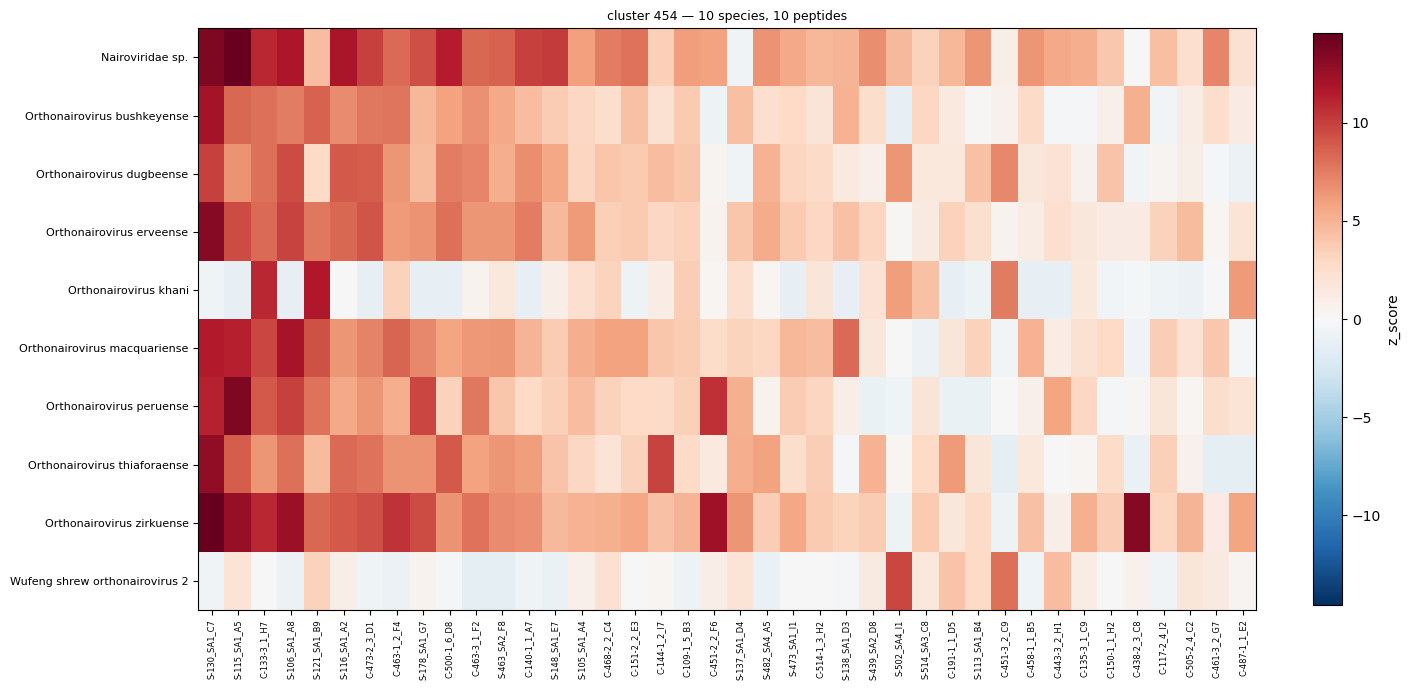

In [ ]:
nairo = crossreactive_clusters(hits, labels, 'Nairoviridae sp.')
print(nairo.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
nairo[["cluster", "species", "protein_std", "sequence"]].head(10)

cid = nairo.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(454, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

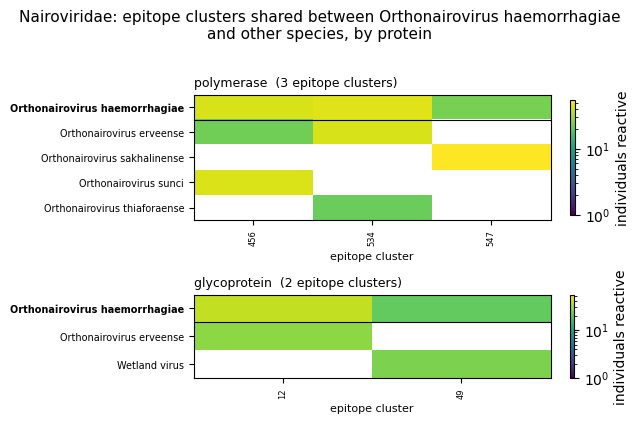

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def nairo_crossreactivity_figure(
        hits, labels, df,
        target='Orthonairovirus haemorrhagiae',
        family='Nairoviridae',
        proteins=None, cross_only=True,
        reactive_col='reactive', figsize_scale=(0.30, 0.26)):
    h = hits.copy()
    h['cluster'] = h.index.map(labels)
    h = h[h.family == family]
    if proteins is not None:
        h = h[h.protein_std.isin(proteins)]

    react = df[df[reactive_col]].groupby('peptide')['individual'].nunique()
    h['n_ind'] = h.index.map(react).fillna(0)

    tgt_cl = set(h.loc[h.species == target, 'cluster'])
    h = h[h.cluster.isin(tgt_cl)]
    if cross_only:
        multi = h.groupby('cluster')['species'].nunique()
        h = h[h.cluster.isin(multi[multi > 1].index)]
    if h.empty:
        print('no cross-reactive clusters found'); return None, None

    prots = list(h.protein_std.value_counts().index)
    fig, axes = plt.subplots(
        len(prots), 1, squeeze=False,
        figsize=(max(6, figsize_scale[0] * h.cluster.nunique() + 5),
                 sum(figsize_scale[1] * h[h.protein_std == p].species.nunique() + 1.1
                     for p in prots)),
        gridspec_kw={'height_ratios': [h[h.protein_std == p].species.nunique() + 1
                                       for p in prots]})

    vmax = max(1, h.n_ind.max())
    for ax, prot in zip(axes.ravel(), prots):
        sub = h[h.protein_std == prot]
        piv = sub.pivot_table(index='species', columns='cluster',
                              values='n_ind', aggfunc='max')
        rows = ([target] if target in piv.index else []) + \
               list(piv.drop(index=target, errors='ignore')
                       .notna().sum(1).sort_values(ascending=False).index)
        piv = piv.reindex(rows)
        piv = piv[piv.notna().sum(0).sort_values(ascending=False).index]

        im = ax.imshow(piv.to_numpy(), aspect='auto', cmap='viridis',
                       norm=LogNorm(vmin=1, vmax=vmax))
        ax.set_xticks(range(piv.shape[1]))
        ax.set_xticklabels(piv.columns, fontsize=6, rotation=90)
        ax.set_yticks(range(len(piv)))
        ax.set_yticklabels([s[:42] for s in piv.index], fontsize=7)
        if target in piv.index:
            ax.get_yticklabels()[list(piv.index).index(target)].set_fontweight('bold')
            ax.axhline(list(piv.index).index(target) + .5, color='k', lw=.8)
        ax.set_title(f'{prot}  ({piv.shape[1]} epitope clusters)', fontsize=9, loc='left')
        ax.set_xlabel('epitope cluster', fontsize=8)
        plt.colorbar(im, ax=ax, fraction=.015, label='individuals reactive')

    fig.suptitle(f'{family}: epitope clusters shared between {target}\n'
                 f'and other species, by protein', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, .97])
    return fig, h


fig, sub = nairo_crossreactivity_figure(hits, labels, df)

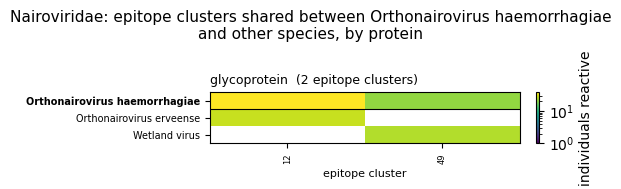

In [ ]:
# only the immunodominant proteins, for a main-text panel
fig, sub = nairo_crossreactivity_figure(hits, labels, df,
                                        proteins=['nucleoprotein','glycoprotein'])


(<Figure size 860x954 with 6 Axes>,
                                                     sensitivity  specificity  \
 peptide                                                                        
 AAB58486.1|precursor|Pichinde_virus|temperature...     0.052897          1.0   
 ABC71137.1|protein|Mammarenavirus_mopeiaense|?|...     0.068010          1.0   
 ABI96821.1|protein|Mammarenavirus_choriomeningi...     0.513854          1.0   
 ADX32837.1|nucleoprotein|Gbagroube_virus|?|Mus_...     0.146096          1.0   
 AFI42021.1|precursor|Mammarenavirus_choriomenin...     0.068010          1.0   
 AFY05618.1|protein|Mopeia_Lassa_virus_reassorta...     0.299748          1.0   
 AIT17661.1|polymerase|Mammarenavirus_lassaense|...     0.078086          1.0   
 ANH09741.1|nucleoprotein|Mammarenavirus_lassaen...     0.173804          1.0   
 ATL14550.1|protein|Mammarenavirus_wenzhouense|G...     0.060453          1.0   
 AVN98160.1|polymerase|Mammarenavirus_lassaense|...     0.062972         

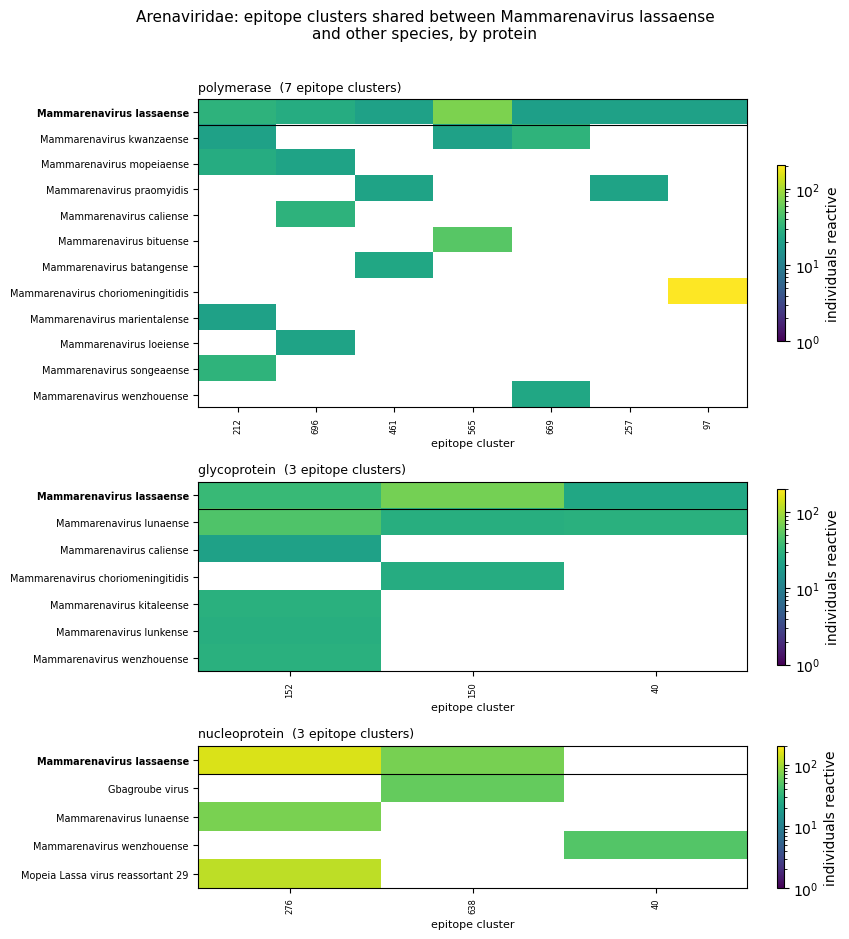

In [ ]:
nairo_crossreactivity_figure(hits, labels, df, target='Mammarenavirus lassaense', family='Arenaviridae')

(<Figure size 600x428 with 4 Axes>,
                                                     sensitivity  specificity  \
 peptide                                                                        
 AXR85443.1|protein|Maripa_virus|isolate=Dos|Hom...     0.052897          1.0   
 BAA05016.1|protein|Orthohantavirus_hantanense|i...     0.294710          1.0   
 BCH41978.1|glycoprotein|Anjozorobe_virus|isolat...     0.068010          1.0   
 QFX79481.1|protein|Orthohantavirus_jejuense|iso...     0.070529          1.0   
 WEU70804.1|protein|Hantaviridae_sp.|isolate=HV/...     0.113350          1.0   
 WPV62114.1|protein|Huangpi_virus|isolate=WZ_Pi....     0.143577          1.0   
 XHP16135.1|glycoprotein|Orthohantavirus_hantane...     0.065491          1.0   
 YP_009361841.1|precursor|Bruges_virus|isolate=?...     0.052897          1.0   
 
                                                                                           sequence  \
 peptide                                         

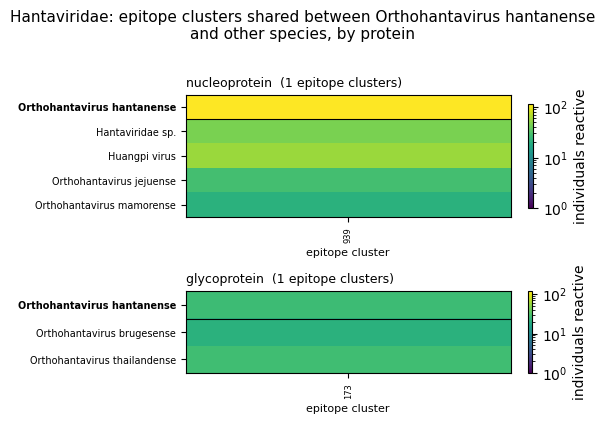

In [ ]:
nairo_crossreactivity_figure(hits, labels, df, target='Orthohantavirus hantanense', family='Hantaviridae')

In [ ]:
"""Where does reactivity resolve in the taxonomy?

Each epitope cluster is assigned to its lowest common ancestor (LCA) across the
peptides it contains. A cluster spanning several species of one genus resolves
at that genus; a cluster confined to one species resolves at the leaf. Plotting
the tree with nodes sized by resolved clusters shows, in one panel, which
reactivity is genus-generic (cross-reactive) and which is species-specific.
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LEVELS = ["family", "genus", "species"]


def assign_lca(hits, labels, df=None, levels=LEVELS, reactive_col="reactive"):
    """Per cluster: the deepest taxonomic level shared by all its peptides."""
    h = hits.copy()
    h["cluster"] = h.index.map(labels)

    n_ind = None
    if df is not None:
        r = df[df[reactive_col]].copy()
        r["cluster"] = r.peptide.map(labels)
        n_ind = r.groupby("cluster")["individual"].nunique()

    rows = []
    for cid, g in h.groupby("cluster"):
        lca_level, lca_taxon = None, None
        for lvl in levels:                      # shallow -> deep
            if g[lvl].nunique() == 1:
                lca_level, lca_taxon = lvl, g[lvl].iloc[0]
            else:
                break
        rows.append({
            "cluster": cid,
            "lca_level": lca_level or "root",
            "lca_taxon": lca_taxon or "root",
            "n_peptides": len(g),
            "n_species": g["species"].nunique(),
            "n_individuals": int(n_ind.get(cid, 0)) if n_ind is not None else np.nan,
        })
    return pd.DataFrame(rows)


def plot_taxonomy_flow(hits, labels, df=None, levels=LEVELS,
                       min_individuals=1, max_species_per_genus=12,
                       size_scale=55, figsize=None, label_species=True):
    """Taxonomic tree; node area = epitope clusters resolving there."""
    lca = assign_lca(hits, labels, df, levels)
    if min_individuals > 1 and lca.n_individuals.notna().any():
        lca = lca[lca.n_individuals >= min_individuals]

    h = hits.copy(); h["cluster"] = h.index.map(labels)

    # how much resolves at each node
    res = (lca.groupby(["lca_level", "lca_taxon"])
              .agg(n_clusters=("cluster", "size"),
                   n_ind=("n_individuals", "sum")).reset_index())
    weight = {(r.lca_level, r.lca_taxon): r.n_clusters for r in res.itertuples()}
    ind_w  = {(r.lca_level, r.lca_taxon): r.n_ind      for r in res.itertuples()}

    # build the tree from taxa actually present, keep the busiest species
    tax = h[levels].drop_duplicates()
    keep = []
    for gen, sub in tax.groupby("genus"):
        sp_w = {s: weight.get(("species", s), 0) for s in sub.species}
        order = sorted(sp_w, key=lambda s: -sp_w[s])[:max_species_per_genus]
        keep += [(sub.family.iloc[0], gen, s) for s in order]
    tax = pd.DataFrame(keep, columns=levels)

    # layout: leaves evenly spaced, parents at mean of children
    tax = tax.sort_values(levels)
    ypos, y = {}, 0.0
    for sp in tax.species:
        ypos[("species", sp)] = y; y += 1
    for gen, sub in tax.groupby("genus"):
        ypos[("genus", gen)] = np.mean([ypos[("species", s)] for s in sub.species])
    for fam, sub in tax.groupby("family"):
        ypos[("family", fam)] = np.mean([ypos[("genus", g)] for g in sub.genus.unique()])

    X = {"family": 0.0, "genus": 1.0, "species": 2.0}
    n_leaves = sum(1 for k in ypos if k[0] == "species")
    if figsize is None:                      # scale height to the tree
        figsize = (13, max(4.0, 0.34 * n_leaves + 2.2))
    fig, ax = plt.subplots(figsize=figsize)

    for r in tax.itertuples():                       # edges
        ax.plot([X["family"], X["genus"]],
                [ypos[("family", r.family)], ypos[("genus", r.genus)]],
                color="0.8", lw=.9, zorder=1)
        ax.plot([X["genus"], X["species"]],
                [ypos[("genus", r.genus)], ypos[("species", r.species)]],
                color="0.85", lw=.7, zorder=1)

    vmax = max([v for v in ind_w.values() if np.isfinite(v)] + [1])
    for (lvl, taxon), yy in ypos.items():
        w = weight.get((lvl, taxon), 0)
        ind = ind_w.get((lvl, taxon), 0)
        if w == 0:
            ax.scatter(X[lvl], yy, s=8, c="white", edgecolors="0.7",
                       lw=.6, zorder=3)
        else:
            ax.scatter(X[lvl], yy, s=size_scale * w, zorder=3,
                       c=[ind / vmax if np.isfinite(ind) else .5],
                       cmap="viridis", vmin=0, vmax=1,
                       edgecolors="k", linewidths=.5)
            if w >= 3:                       # only label nodes big enough to read
                ax.annotate(f"{int(w)}", (X[lvl], yy), fontsize=6.5, ha="center",
                            va="center", color="w", zorder=4, fontweight="bold")
        if lvl != "species" or label_species:
            dx = 0.012 * np.sqrt(size_scale * max(w, 1)) + 0.05
            txt = f"{taxon[:38]}" + (f"  ({int(w)})" if 0 < w < 3 else "")
            ax.annotate(txt, (X[lvl] + dx, yy), fontsize=7.2,
                        va="center", ha="left", zorder=4)

    for lvl, x in X.items():
        ax.annotate(lvl.upper(), (x, -1.1), fontsize=9, ha="left",
                    fontweight="bold", color="0.35")

    ax.set_xlim(-.25, 3.3); ax.set_ylim(-1.7, max(ypos.values()) + 0.8)
    ax.invert_yaxis(); ax.axis("off")

    counts = lca.lca_level.value_counts()
    sub = " | ".join(f"{k}: {v} clusters" for k, v in counts.items())
    ax.set_title("Where epitope reactivity resolves in the taxonomy\n"
                 "node area = clusters whose lowest common ancestor is that taxon; "
                 "colour = individuals reactive\n" + sub, fontsize=10, loc="left")
    ax.legend(handles=[Line2D([], [], marker="o", ls="", mfc="0.6", mec="k",
                              ms=np.sqrt(size_scale * n) / 2.2,
                              label=f"{n} cluster{'s' if n > 1 else ''}")
                       for n in (1, 5, 20)],
              loc="lower right", frameon=False, fontsize=8, labelspacing=1.6)
    fig.tight_layout()
    return fig, lca


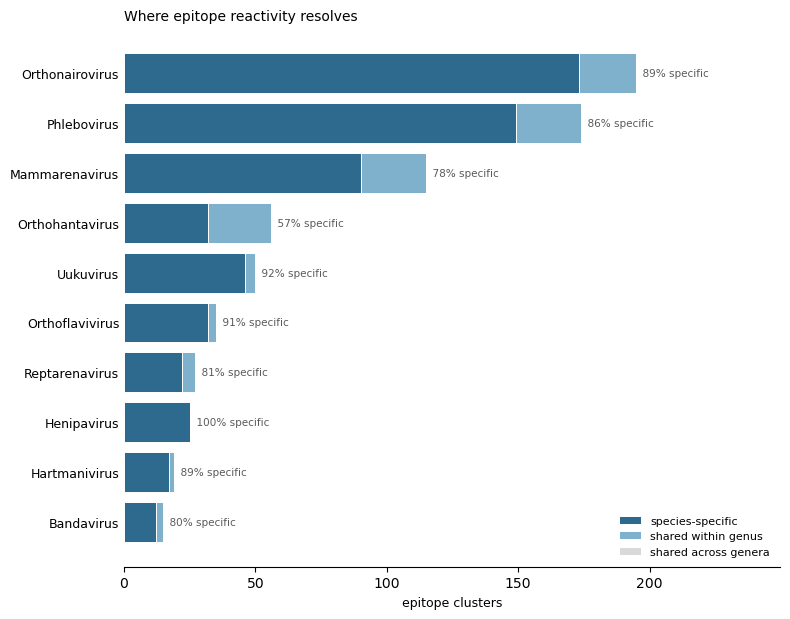

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

LEVELS = ["family", "genus", "species"]

def assign_lca(hits, labels, df=None, levels=LEVELS, reactive_col="reactive"):
    """Per cluster: the deepest taxonomic level shared by all its peptides."""
    h = hits.copy()
    h["cluster"] = h.index.map(labels)

    n_ind = None
    if df is not None:
        r = df[df[reactive_col]].copy()
        r["cluster"] = r.peptide.map(labels)
        n_ind = r.groupby("cluster")["individual"].nunique()

    rows = []
    for cid, g in h.groupby("cluster"):
        lca_level, lca_taxon = None, None
        for lvl in levels:                      # shallow -> deep
            if g[lvl].nunique() == 1:
                lca_level, lca_taxon = lvl, g[lvl].iloc[0]
            else:
                break
        rows.append({
            "cluster": cid,
            "lca_level": lca_level or "root",
            "lca_taxon": lca_taxon or "root",
            "n_peptides": len(g),
            "n_species": g["species"].nunique(),
            "n_individuals": int(n_ind.get(cid, 0)) if n_ind is not None else np.nan,
        })
    return pd.DataFrame(rows)

def plot_resolution_summary(hits, labels, df=None, levels=LEVELS,
                            min_individuals=1, top_n=10, ax=None,
                            colors=("#2d6a8e", "#7fb0cc", "#d9d9d9")):
    lca = assign_lca(hits, labels, df, levels)
    if min_individuals > 1 and lca.n_individuals.notna().any():
        lca = lca[lca.n_individuals >= min_individuals]

    h = hits.copy(); h["cluster"] = h.index.map(labels)
    genus_of = h.groupby("cluster")["genus"].agg(
        lambda s: s.iloc[0] if s.nunique() == 1 else "multi-genus")
    lca["genus"] = lca.cluster.map(genus_of)

    lca["resolution"] = np.where(lca.lca_level == "species", "species-specific",
                         np.where(lca.lca_level == "genus", "shared within genus",
                                  "shared across genera"))

    lca = lca[lca.genus != "multi-genus"]     # after computing, before plotting

    order = lca.genus.value_counts().index[:top_n][::-1]
    cats = ["species-specific", "shared within genus", "shared across genera"]
    tab = (lca[lca.genus.isin(order)]
           .pivot_table(index="genus", columns="resolution", values="cluster",
                        aggfunc="count", fill_value=0)
           .reindex(index=order, columns=cats, fill_value=0))

    if ax is None:
        _, ax = plt.subplots(figsize=(8, .45 * len(tab) + 1.8))
    left = np.zeros(len(tab))
    for cat, c in zip(cats, colors):
        ax.barh(tab.index, tab[cat], left=left, color=c, label=cat,
                edgecolor="white", linewidth=.7)
        left += tab[cat].to_numpy()

    for i, (g, tot) in enumerate(zip(tab.index, left)):
        pct = 100 * tab.loc[g, "species-specific"] / tot if tot else 0
        ax.annotate(f"  {pct:.0f}% specific", (tot, i), va="center",
                    fontsize=7.5, color="0.35")

    ax.set_xlabel("epitope clusters", fontsize=9)
    ax.set_xlim(0, left.max() * 1.28)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=9)
    ax.set_title("Where epitope reactivity resolves", fontsize=10, loc="left")
    plt.tight_layout()
    return ax, lca


ax, lca = plot_resolution_summary(hits, labels, df)

In [ ]:
def inspect_genus(hits, labels, df, genus, level="genus",
                  reactive_col="reactive", top=15):
    """
    Pull apart one genus's shared-epitope signal: which clusters span multiple
    species, which proteins they sit in, and how many individuals per cohort.
    """
    h = hits.copy(); h["cluster"] = h.index.map(labels)
    h = h[h[level] == genus]
    if h.empty:
        print(f"no hits for {genus}"); return None

    size = h.groupby("cluster").size()
    nsp  = h.groupby("cluster")["species"].nunique()
    shared = nsp[nsp > 1].index

    r = df[df[reactive_col] & df.peptide.isin(h.index)].copy()
    r["cluster"] = r.peptide.map(labels)
    ind = r.groupby("cluster")["individual"].nunique()
    coh = (r.drop_duplicates(["cluster", "individual"])
             .groupby(["cluster", "cohort"]).size().unstack(fill_value=0)
           if "cohort" in r.columns else None)

    rows = []
    for cid in shared:
        g = h[h.cluster == cid]
        rec = {"cluster": cid,
               "n_peptides": int(size[cid]),
               "n_species": int(nsp[cid]),
               "n_individuals": int(ind.get(cid, 0)),
               "proteins": ";".join(sorted(set(g.protein_std))),
               "species": ";".join(sorted(set(g.species))[:3])}
        if coh is not None and cid in coh.index:
            for c in coh.columns:
                rec[f"n_{c}"] = int(coh.loc[cid, c])
        rows.append(rec)

    out = (pd.DataFrame(rows).sort_values("n_individuals", ascending=False)
             .reset_index(drop=True))
    print(f"{genus}: {len(size)} clusters, {len(shared)} genus-shared "
          f"({(size==1).sum()} singletons)")
    print(f"  proteins: {dict(h[h.cluster.isin(shared)].protein_std.value_counts().head(4))}")
    if coh is not None:
        tot = r.drop_duplicates(['cluster','individual']).groupby('cohort').individual.nunique()
        print(f"  reactive individuals by cohort: {dict(tot)}")
    return out.head(top)

In [ ]:
oh = inspect_genus(hits, labels, df, 'Orthohantavirus')
oh

Orthohantavirus: 60 clusters, 27 genus-shared (32 singletons)
  proteins: {'polymerase': np.int64(38), 'glycoprotein': np.int64(32), 'nucleoprotein': np.int64(10), 'polyprotein': np.int64(1)}
  reactive individuals by cohort: {'SL': np.int64(397)}


,cluster,n_peptides,n_species,n_individuals,proteins,species,n_SL
0,939,4,4,157,nucleoprotein,Huangpi virus;Orthohantavirus hantanense;Ortho...,157
1,131,9,9,136,polymerase,Huangpi virus;Kilimanjaro virus;Limestone Cany...,136
2,310,7,7,130,glycoprotein,Orthohantavirus andesense;Orthohantavirus bayo...,130
3,67,2,2,94,glycoprotein,Orthohantavirus delgaditoense;Orthohantavirus ...,94
4,778,3,3,90,polymerase,Orthohantavirus khabarovskense;Orthohantavirus...,90
5,538,3,3,86,polymerase,Orthohantavirus artybashense;Orthohantavirus b...,86
6,775,3,3,85,polymerase,Huangpi virus;Orthohantavirus artybashense;Ort...,85
7,190,3,3,83,polymerase,Orthohantavirus andesense;Orthohantavirus carr...,83
8,625,4,4,83,nucleoprotein,Amga virus;Orthohantavirus artybashense;Orthoh...,83
9,176,3,3,81,glycoprotein;polyprotein,Orthohantavirus dobravaense;Orthohantavirus se...,81


(<Figure size 1300x5388 with 1 Axes>,
      cluster lca_level                         lca_taxon  n_peptides  \
 0          1   species                      Seewis virus           1   
 1          2   species            Thottimvirus imjinense           1   
 2          3   species            Mobatvirus xuansonense           1   
 3          4   species                Percilovirus gobii           1   
 4          5   species           Mammarenavirus loeiense           1   
 ..       ...       ...                               ...         ...   
 940      941   species         Actinovirus triacanthodis           1   
 941      942   species  Stubbeard plunderfish hantavirus           1   
 942      943   species            Alphavirus chikungunya           1   
 943      944   species           Uukuvirus uukuniemiense           1   
 944      945   species             Antennavirus hirsutum           1   
 
      n_species  n_individuals  
 0            1             22  
 1            1   

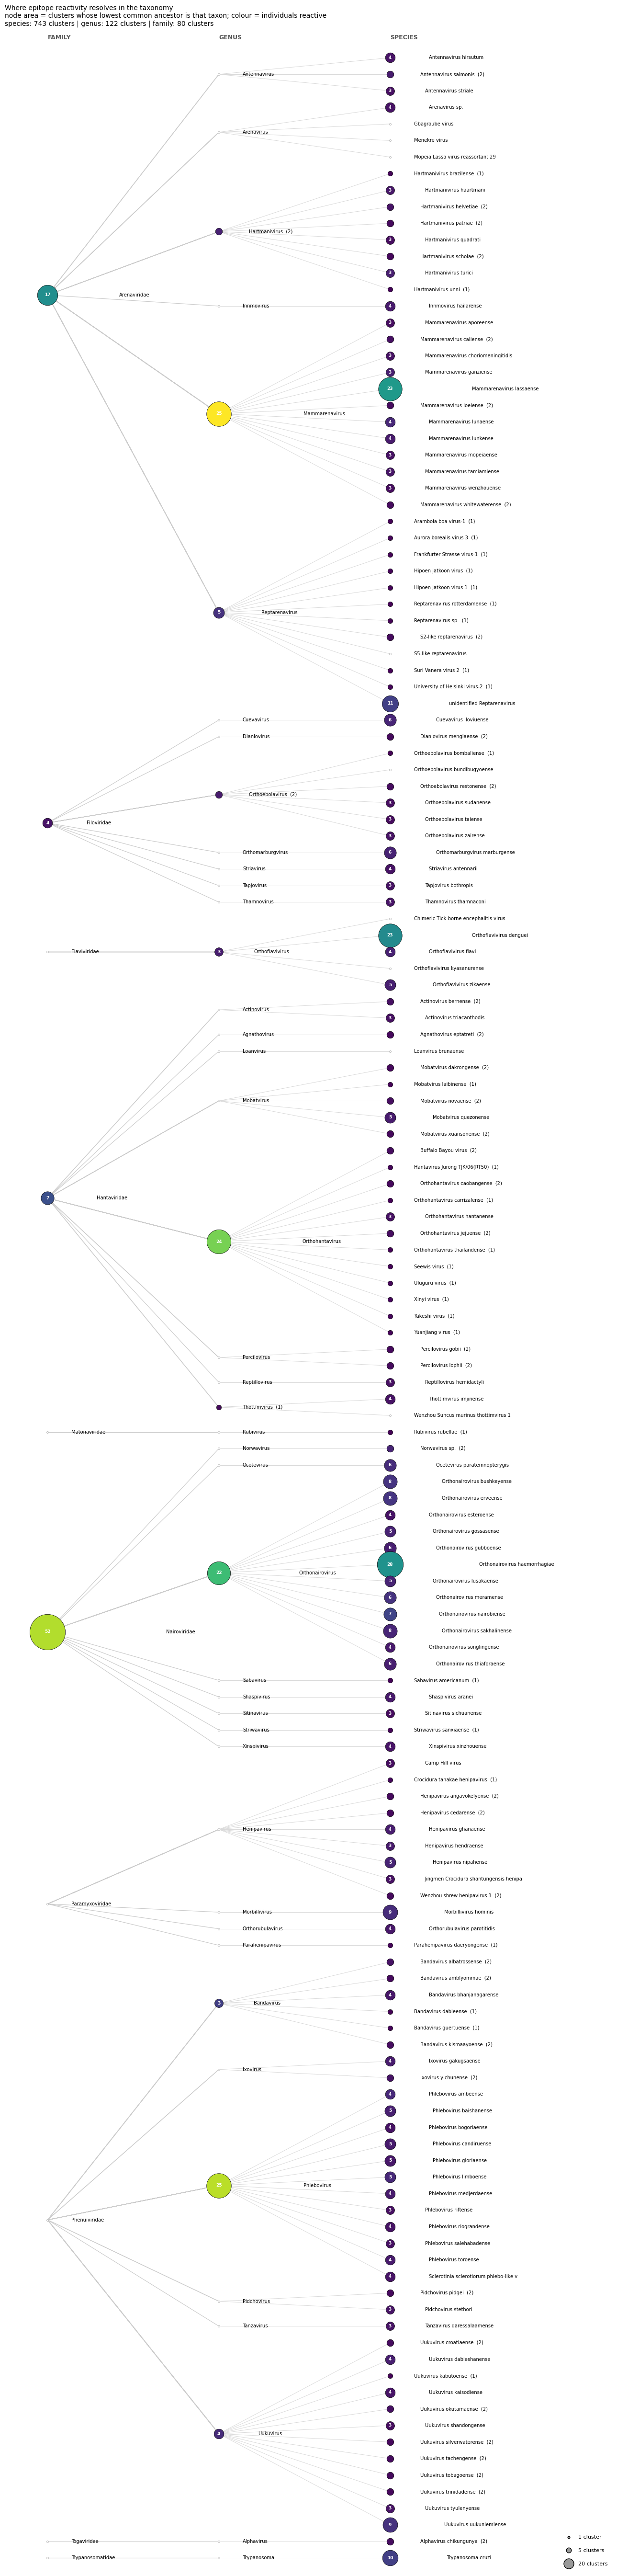

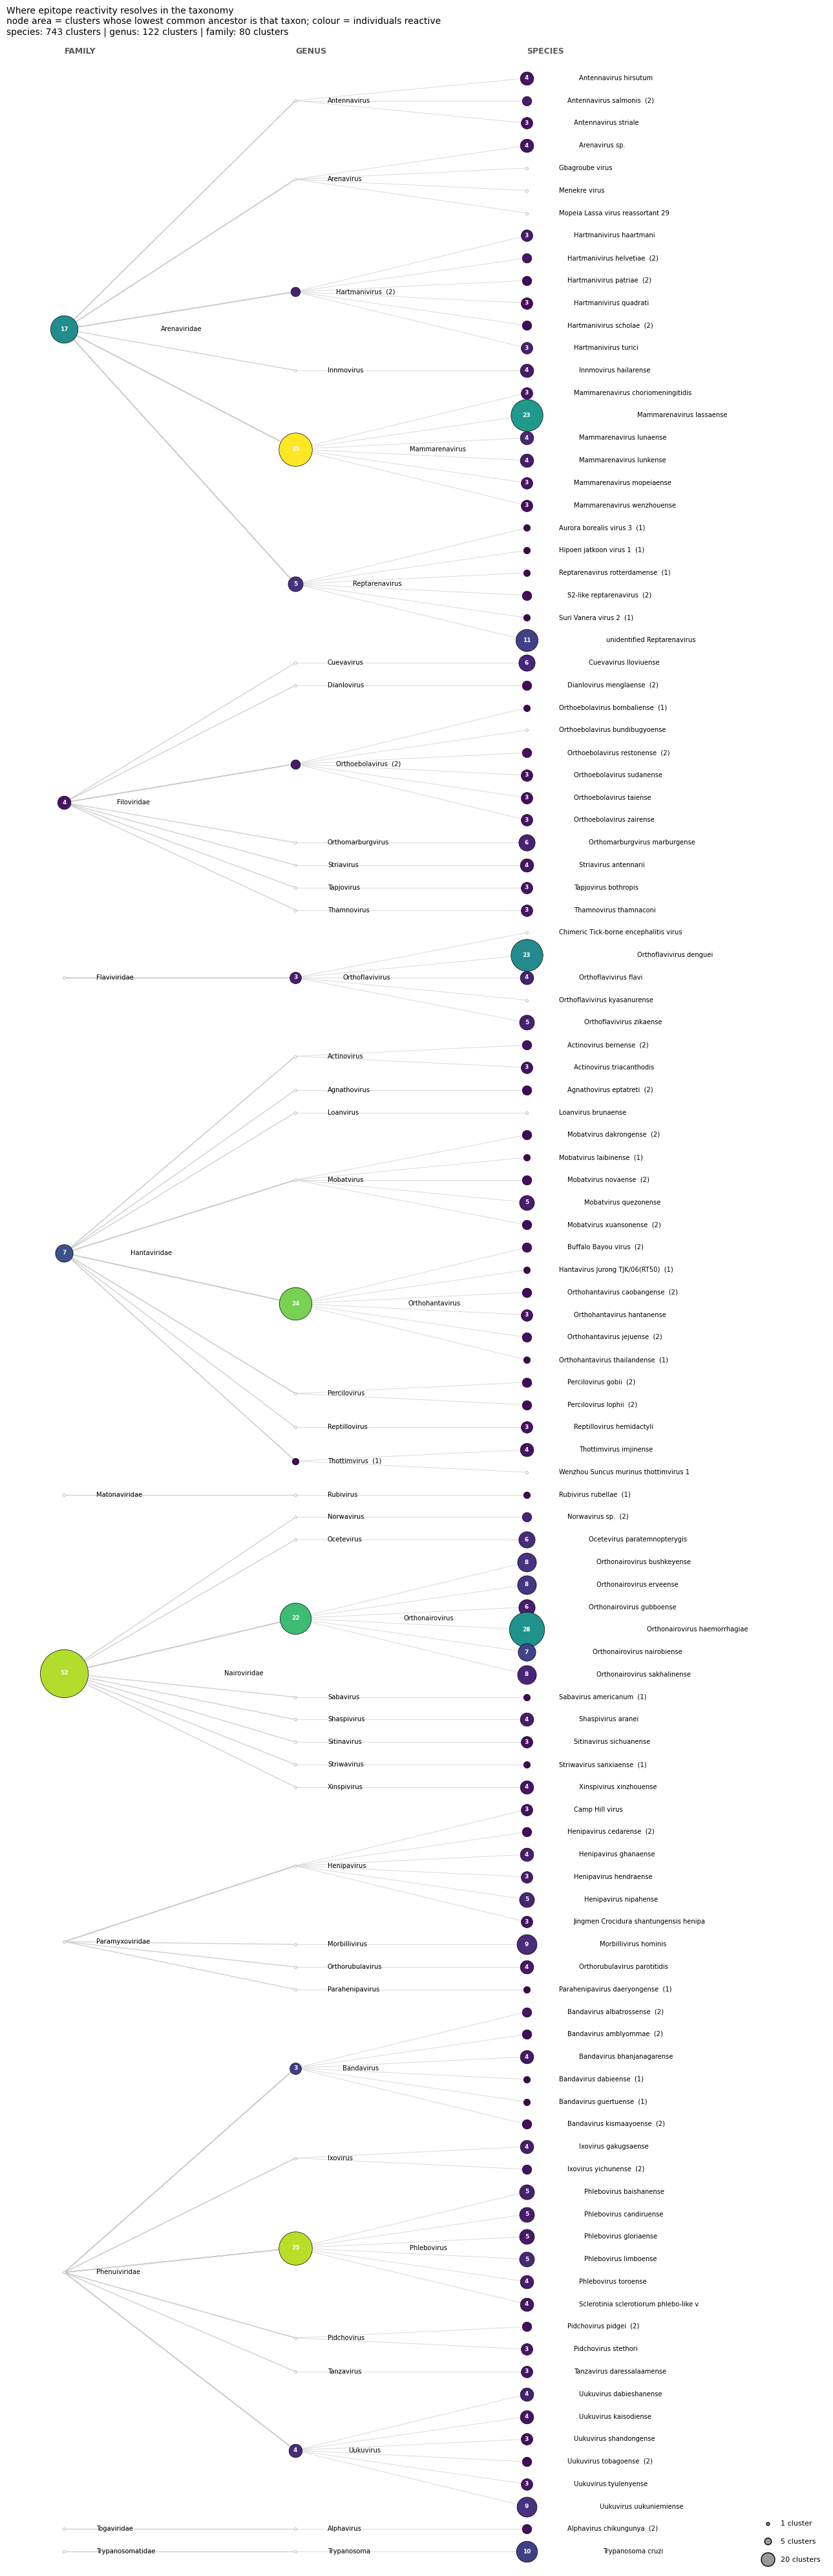

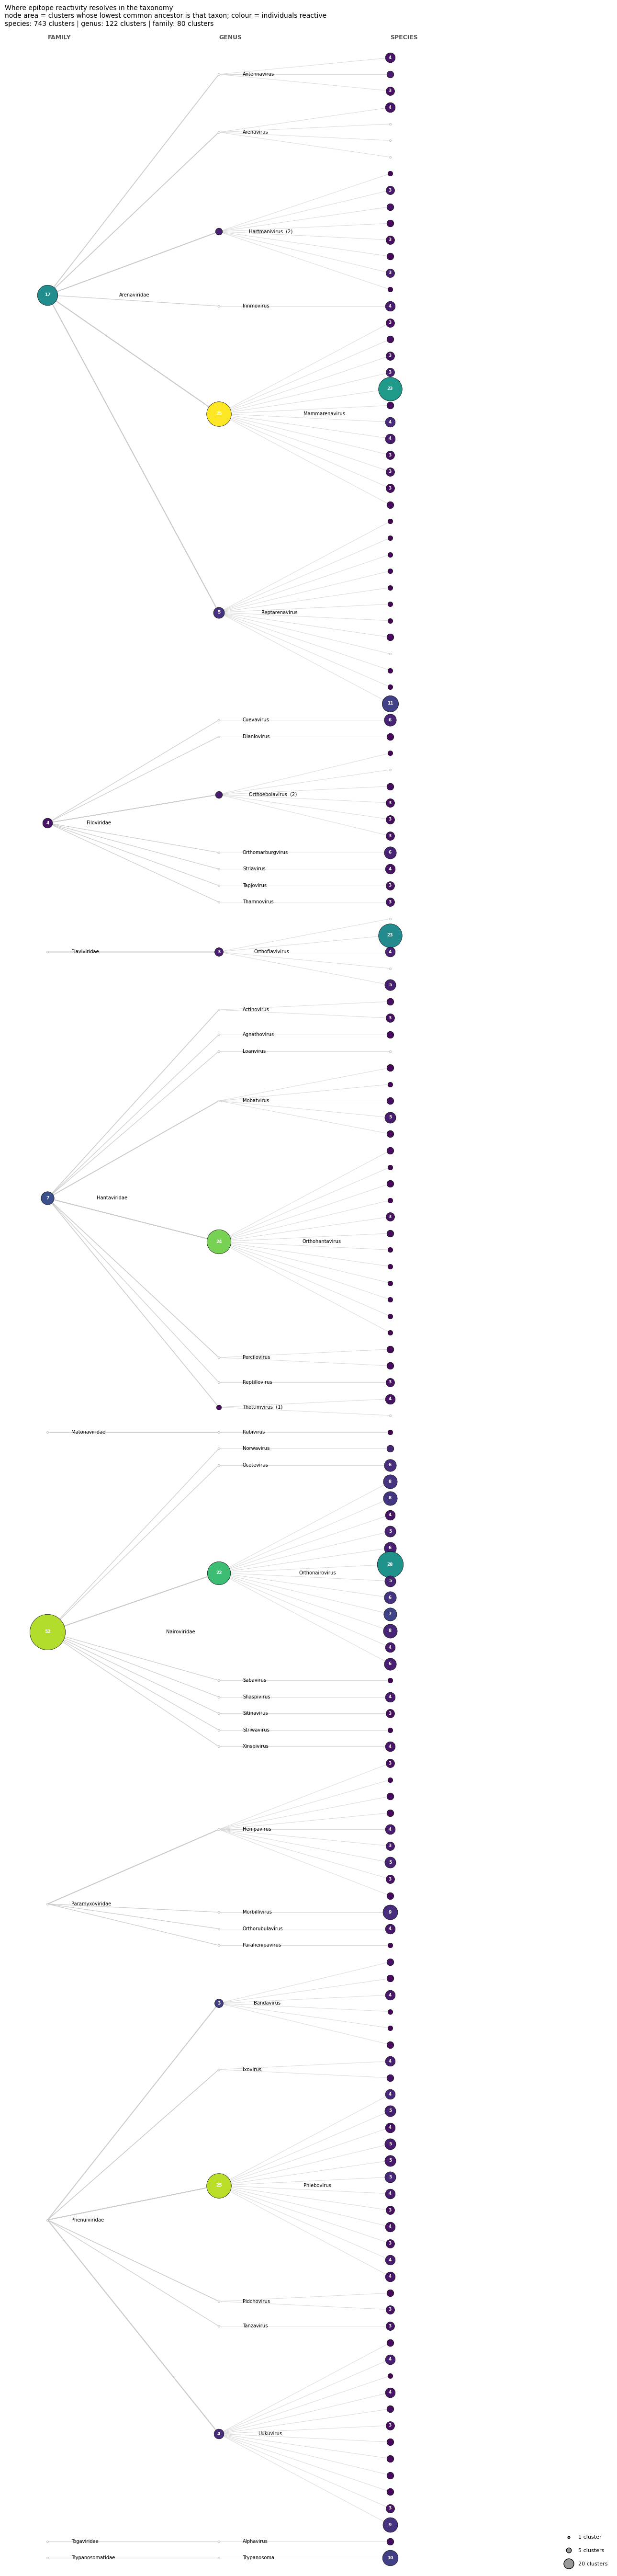

In [ ]:
plot_taxonomy_flow(hits, labels, df, min_individuals=3)        # drop singleton-person clusters
plot_taxonomy_flow(hits, labels, df, max_species_per_genus=6)  # trim crowded genera
plot_taxonomy_flow(hits, labels, df, label_species=False)      # dense version

## broad genus -level reactivity 

In [ ]:
def taxon_crossreactivity_figure(
        hits, labels, df, taxon, level='genus', target=None,
        proteins=None, cross_only=True, reactive_col='reactive',
        min_species=2, max_clusters=None, cell=(0.30, 0.26)):
    """
    Cluster x species map for a whole taxon, one panel per protein.

    target=None  -> genus-wide view: every cluster spanning >= min_species.
                    Use when reactivity is spread across species with no single
                    one dominating -- the figure shows whether that apparent
                    breadth collapses onto a few shared epitopes.
    target='...' -> that species is pinned as the top row and only clusters
                    containing it are shown.
    """
    h = hits.copy()
    h['cluster'] = h.index.map(labels)
    h = h[h[level] == taxon]
    if proteins is not None:
        h = h[h.protein_std.isin(proteins)]
    if h.empty:
        print(f'no hits for {taxon}'); return None, None

    react = df[df[reactive_col]].groupby('peptide')['individual'].nunique()
    h['n_ind'] = h.index.map(react).fillna(0)

    if target is not None:
        h = h[h.cluster.isin(set(h.loc[h.species == target, 'cluster']))]
    if cross_only:
        multi = h.groupby('cluster')['species'].nunique()
        h = h[h.cluster.isin(multi[multi >= min_species].index)]
    if h.empty:
        print('no cross-reactive clusters found'); return None, None
    if max_clusters:
        top = (h.groupby('cluster')['species'].nunique()
                .sort_values(ascending=False).index[:max_clusters])
        h = h[h.cluster.isin(top)]

    prots = list(h.protein_std.value_counts().index)
    fig, axes = plt.subplots(
        len(prots), 1, squeeze=False,
        figsize=(max(6, cell[0] * h.cluster.nunique() + 5),
                 sum(cell[1] * h[h.protein_std == p].species.nunique() + 1.2
                     for p in prots)),
        gridspec_kw={'height_ratios': [h[h.protein_std == p].species.nunique() + 1
                                       for p in prots]})

    vmax = max(1, h.n_ind.max())
    for ax, prot in zip(axes.ravel(), prots):
        sub = h[h.protein_std == prot]
        piv = sub.pivot_table(index='species', columns='cluster',
                              values='n_ind', aggfunc='max')
        rows = list(piv.notna().sum(axis=1).sort_values(ascending=False).index)
        if target in piv.index:
            rows = [target] + [r for r in rows if r != target]
        piv = piv.reindex(rows)
        piv = piv[piv.notna().sum(axis=0).sort_values(ascending=False).index]

        im = ax.imshow(piv.to_numpy(), aspect='auto', cmap='viridis',
                       norm=LogNorm(vmin=1, vmax=vmax))
        ax.set_xticks(range(piv.shape[1]))
        ax.set_xticklabels(piv.columns, fontsize=6, rotation=90)
        ax.set_yticks(range(len(piv)))
        ax.set_yticklabels([s[:42] for s in piv.index], fontsize=7)
        if target in piv.index:
            ax.get_yticklabels()[0].set_fontweight('bold')
            ax.axhline(.5, color='k', lw=.8)
        ax.set_title(f'{prot}  —  {piv.shape[1]} epitope clusters span '
                     f'{piv.notna().any(axis=1).sum()} species', fontsize=9, loc='left')
        ax.set_xlabel('epitope cluster', fontsize=8)
        plt.colorbar(im, ax=ax, fraction=.015, label='individuals reactive')

    fig.suptitle(f'{taxon}: shared epitope clusters across species, by protein',
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, .97])
    return fig, h


def breadth_collapse_summary(hits, labels, df, taxon, level='genus',
                             reactive_col='reactive'):
    """
    The number the genus-wide figure is making: apparent species breadth vs
    independent epitope clusters, per individual.
    """
    h = hits.copy(); h['cluster'] = h.index.map(labels)
    h = h[h[level] == taxon]
    r = df[df[reactive_col] & df.peptide.isin(h.index)].copy()
    r['cluster'] = r.peptide.map(labels)
    r['species'] = r.peptide.map(h['species'])

    out = r.groupby('individual').agg(
        n_peptides=('peptide', 'nunique'),
        n_species_apparent=('species', 'nunique'),
        n_epitope_clusters=('cluster', 'nunique'))
    meta = df.drop_duplicates('individual').set_index('individual')
    if 'cohort' in meta.columns:
        out['cohort'] = meta['cohort']
    return out

KeyboardInterrupt: 

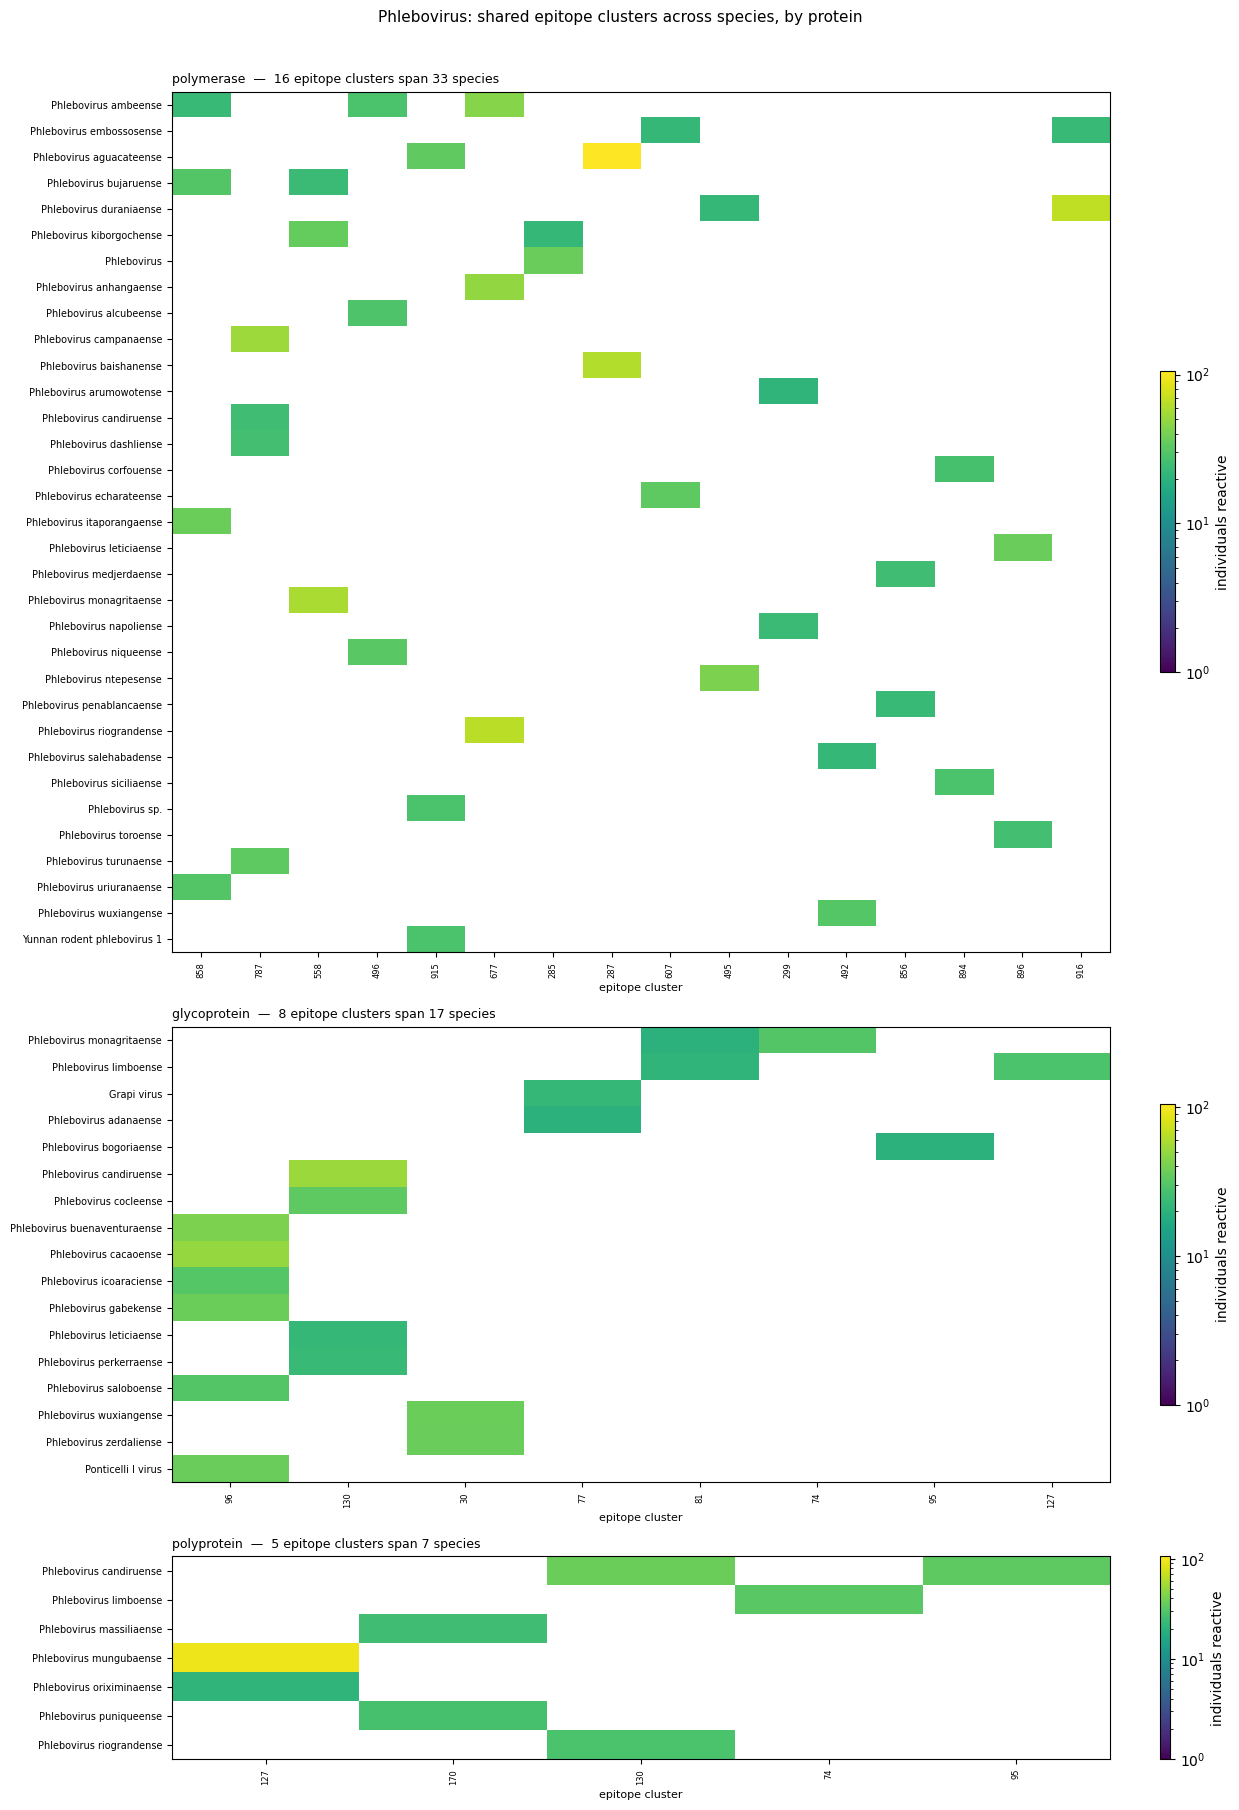

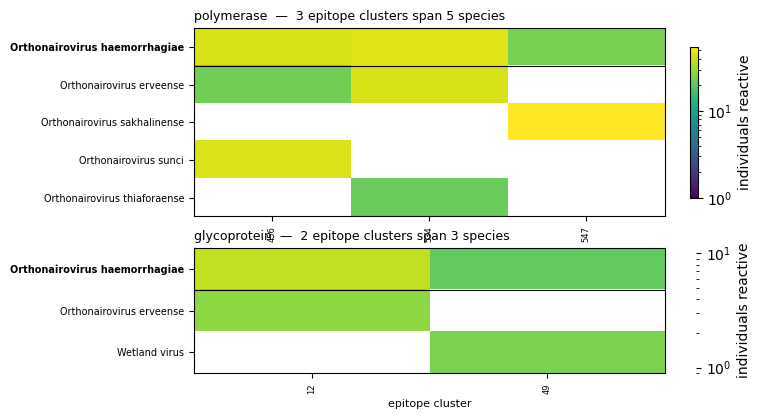

In [ ]:
# genus-wide: every cluster spanning >=2 Phlebovirus species
fig, sub = taxon_crossreactivity_figure(hits, labels, df, 'Phlebovirus')

# pin one species as the top row (the CCHFV version)
fig, sub = taxon_crossreactivity_figure(hits, labels, df, 'Orthonairovirus',
                                        target='Orthonairovirus haemorrhagiae')

# --------

In [ ]:
def describe_collapse(hits, labels):
    h = hits.copy()
    h['cluster'] = h.index.map(labels) #attach cluster labels
    sizes = h.groupby('cluster').size() #calculate cluster sizes
    rows = []
    for cid, grp in h[h.cluster.isin(sizes[sizes > 1].index)].groupby('cluster'): #ignore clusters where there is only one peptide
        #then for each cluster ID, give me the rows belonging to that cluster at grp.
        n_fam, n_gen, n_sp, n_acc = (grp[c].nunique() for c in ['family','genus','species','accession']) #is calculating grp['family'].nunique() etc.
        # give me column c from the dataframe grp. 
        kind = ('cross_family'   if n_fam > 1 else
                'cross_genus'    if n_gen > 1 else
                'cross_species'  if n_sp  > 1 else
                'within_species' if n_acc > 1 else 'same_protein')
        rows.append({'cluster': cid, 'n_peptides': len(grp), 'kind': kind,
                     'species_list': ';'.join(sorted(set(grp.species))[:4])})
    out = pd.DataFrame(rows)
    if len(out):
        print(out['kind'].value_counts().to_string())
        return out.sort_values('n_peptides', ascending=False).reset_index(drop=True)
    return out

desc = describe_collapse(hits, labels)
desc.head(20)

kind
cross_species     123
within_species     48
same_protein       14
cross_genus        12


,cluster,n_peptides,kind,species_list
0,99,13,cross_genus,Arenavirus sp.;Erinaceus europaeus arenavirus;...
1,454,10,cross_species,Nairoviridae sp.;Orthonairovirus bushkeyense;O...
2,131,9,cross_species,Huangpi virus;Kilimanjaro virus;Limestone Cany...
3,565,9,cross_species,Mammarenavirus bituense;Mammarenavirus kwanzae...
4,212,8,cross_species,Mammarenavirus kwanzaense;Mammarenavirus lassa...
5,310,7,cross_species,Orthohantavirus andesense;Orthohantavirus bayo...
6,564,7,within_species,Mammarenavirus lassaense
7,276,7,cross_genus,Mammarenavirus lassaense;Mammarenavirus lunaen...
8,642,7,cross_species,Mammarenavirus brazilense;Mammarenavirus pirit...
9,130,6,cross_species,Phlebovirus candiruense;Phlebovirus cocleense;...


In [ ]:
TARGET = ['Orthonairovirus', 'Phlebovirus', "Mammarenavirus"]

h = hits.copy()
h['cluster'] = h.index.map(labels)

fams = h.groupby('cluster')['family'].nunique()
gens = h.groupby('cluster')['genus'].nunique()

tgt = h[h.genus.isin(TARGET)].copy()
tgt['n_fam_in_cluster'] = tgt.cluster.map(fams)

tgt['clean_vs_hits'] = tgt.n_fam_in_cluster == 1



In [ ]:
tgt

,sensitivity,specificity,sequence,accession,protein_name,gene,segment,order,family,subfamily,...,taxonomy_lineage,collection_date,geo_loc_name,host,protein_std,fragment,collection_date_standardized,cluster,n_fam_in_cluster,clean_vs_hits
peptide,,,,,,,,,,,,,,,,,,,,,
AAA47458.1|?|sandfly_fever_Sicilian_virus|isolate=?|?|?|?|segment=?|strain=?|tile_9,0.070529,1.0,LRGAQKRDIEESFSQPMLAAINSSFIDNTQRRAFLTKFGILTSGAR,AAA47458.1,nucleoprotein,NaN,NaN,Hareavirales,Phenuiviridae,NaN,...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,NaN,NaN,nucleoprotein,9,NaN,880,1,True
AAB58486.1|precursor|Pichinde_virus|temperature_sensitive_mutant_ts908|?|?|?|?|?|tile_17,0.052897,1.0,LKQLAKIPYCNYTKFWYINDTITGRHSLPQCWLVHNGSYLNETHFK,AAB58486.1,glycoprotein precursor,NaN,NaN,Hareavirales,Arenaviridae,NaN,...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,NaN,NaN,glycoprotein,17,NaN,152,1,True
AAK17901.1|protein|Mammarenavirus_piritalense|?|?|?|?|S|prototype_strain_VAV-488|tile_16,0.050378,1.0,RNGGSPRLSQLSHAKEEQILEGLKRLDSKATTWIDIEGTPNDPVEL,AAK17901.1,nucleocapsid protein,N,S,Hareavirales,Arenaviridae,NaN,...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,NaN,NaN,nucleoprotein,16,NaN,274,1,True
AAK17901.1|protein|Mammarenavirus_piritalense|?|?|?|?|S|prototype_strain_VAV-488|tile_5,0.050378,1.0,LSKDELMELASDLQKLKKKVLRVEGSGQPGVYAGNLTTTQLEQRSK,AAK17901.1,nucleocapsid protein,N,S,Hareavirales,Arenaviridae,NaN,...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,NaN,NaN,nucleoprotein,5,NaN,642,1,True
AAT88081.1|protein|Mammarenavirus_piritalense|?|Sigmodon_alstoni|Venezuela:_Apure|?|S|1645|tile_13,0.057935,1.0,VLEVKSREKMFVSETPGQRNPYENLLYKLCLSGDGWPYIGSRSQIK,AAT88081.1,nucleocapsid protein,NaN,S,Hareavirales,Arenaviridae,NaN,...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,Venezuela: Apure,Sigmodon alstoni,nucleoprotein,13,NaN,198,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YP_170710.1|protein|Mopeia_virus_AN20410|?|?|Mozambique|?|S|AN20410|tile_17,0.062972,1.0,SQTMELKDSMLQLDPNAKTWIDIEGRPEDPVEIAIYQPNNGQYIHF,YP_170710.1,nucleocapsid protein,NP,S,Hareavirales,Arenaviridae,NaN,...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,Mozambique,NaN,nucleoprotein,17,NaN,277,1,True
YP_170710.1|protein|Mopeia_virus_AN20410|?|?|Mozambique|?|S|AN20410|tile_2,0.083123,1.0,CSNIKIQVIKDAQALLHGLDFSEVANVQRLMRKEKRDDSDLKRLRD,YP_170710.1,nucleocapsid protein,NP,S,Hareavirales,Arenaviridae,NaN,...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,Mozambique,NaN,nucleoprotein,2,NaN,528,1,True
YP_516229.1|protein|Mammarenavirus_praomyidis|?|?|?|?|L|Acar_3080|tile_49,0.055416,1.0,QSYNSQGPDTGRLKFSLSYKEQVGGNRELYIGDLRTKMFTRLIEDY,YP_516229.1,L protein,L,L,Hareavirales,Arenaviridae,NaN,...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,NaN,NaN,NaN,polymerase,49,NaN,461,1,True


In [ ]:
def epitope_breadth(df, labels, reactive_col='reactive'): #only keep reactive peptides
    r = df[df[reactive_col]].copy() #only keep reactive peptides
    r['cluster'] = r['peptide'].map(labels) #give each reactive peptide its cluster id
    g = r.groupby('individual') #want to calculate metrics for each person, creates a new dataframe, out
    out = pd.DataFrame({
        'n_reactive_peptides': g['peptide'].nunique(),
        'n_epitope_clusters':  g['cluster'].nunique(),
        'n_species_apparent':  g['species'].nunique(),
    })
    out['inflation'] = out.n_reactive_peptides / out.n_epitope_clusters.replace(0, np.nan) 
    meta_i = df.drop_duplicates('individual').set_index('individual') #get one row of metadata per individual
    for c in ('cohort', 'category'):
        if c in meta_i.columns:
            out[c] = meta_i[c] #adds cohort and category column to out
    return out

breadth = epitope_breadth(df, labels)
print(breadth.groupby('cohort')[['n_reactive_peptides','n_epitope_clusters',
                                 'n_species_apparent','inflation']].mean().round(2))

        n_reactive_peptides  n_epitope_clusters  n_species_apparent  inflation
cohort                                                                        
SL                    114.0              100.61               86.06       1.13


In [ ]:
breadth

,n_reactive_peptides,n_epitope_clusters,n_species_apparent,inflation,cohort,category
individual,,,,,,
C-109-1_5_B3,120,103,93,1.165049,SL,Household contact
C-109-2_5_B5,105,95,84,1.105263,SL,Household contact
C-109-3_4_E7,114,100,81,1.140000,SL,Household contact
C-110-1_2_A5,71,67,56,1.059701,SL,Household contact
C-110-2_3_F8,83,76,68,1.092105,SL,Household contact
...,...,...,...,...,...,...
S-510_SA3_D5,114,89,89,1.280899,SL,Lassa survivor
S-511_SA5_A6,137,130,101,1.053846,SL,Lassa survivor
S-512_SA3_G9,167,147,125,1.136054,SL,Lassa survivor


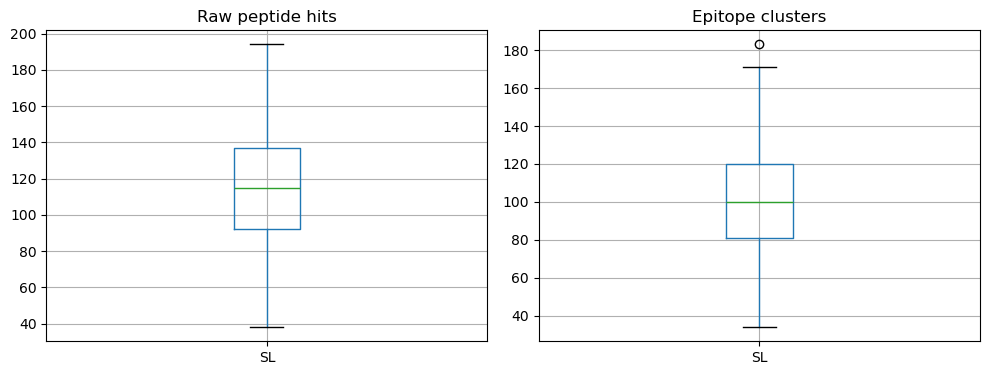

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, col, title in zip(axes, ['n_reactive_peptides','n_epitope_clusters'],
                          ['Raw peptide hits','Epitope clusters']):
    breadth.boxplot(column=col, by='cohort', ax=ax)
    ax.set_title(title); ax.set_xlabel('')
plt.suptitle(''); plt.tight_layout()